(streaming_tick_data)=

# Streaming variational inference on high-frequency tick data

:::{post} August 2026
:tags: variational inference, minibatch, out-of-core, hierarchical model, time series
:category: advanced, tutorial
:author: Yicheng Yang
:::

Financial tick data outgrows memory quickly: one month of Binance aggregated
trades for a single liquid pair is roughly 28 million rows, and a modest
38-symbol universe (four majors over six months plus a one-month tail of 34
alt pairs) already exceeds 450 million rows — far more
than `pm.Minibatch` can hold resident on a 16 GB machine. This notebook fits a
hierarchical hurdle–Student-t model of *next-event price moves* to a dataset of
that scale by streaming minibatches from disk, using the
{class}`~pymc_extras.variational.dataloader.DataLoader` introduced in the
{ref}`streaming_dataset` companion notebook.

The companion covers the mechanics of the streaming API. This notebook is the
applied piece, and it tries to teach three things that only show up on real
data:

1. **When minibatch VI is even valid.** Two acceptance gates that most
   time-series models fail — and a model class that passes both.
2. **The full workflow at scale**: causal feature engineering, an on-disk
   global shuffle, streaming ADVI with `total_size` rescaling, and an online
   stopping rule.
3. **Honest reporting.** Mean-field variational inference on half a billion
   rows produces some numbers you should trust and some you should not; we
   measure which are which instead of guessing.

The notebook itself runs in about a minute on synthetic data with known ground
truth — the streaming code is identical at any scale. Full-scale results on the
real 38-symbol Binance corpus are reported in {ref}`tick-real-corpus`: the data
are public, and every quoted number traces to the run artifacts of the ETL and
fit scripts that accompany the submission.

## Two gates: when minibatch VI is valid, and when it is worth it

Minibatch variational inference rests on one identity: if the likelihood
factors over rows given the parameters, then the batch log-likelihood scaled by
$N/B$ is an unbiased estimator of the full-data log-likelihood
{cite:p}`hoffman2013stochastic`. Two gates shaped this notebook's model — the
first is about *validity*, the second about whether streaming is doing any
real work — and they are worth internalizing before reaching for `total_size`
on your own data:

**Gate 1 — validity: the likelihood must factor over rows, sampled uniformly.**
No latent path coupling observations, no label shared across rows, and every
row given the same inclusion probability by the batching scheme (unequal
inclusion breaks the plain $N/B$ rescaling). This is exactly why the classic
stochastic volatility model of the {ref}`stochastic_volatility` notebook
*cannot* be minibatched: its latent volatility path ties every observation to
its neighbours, so a random subset of rows does not carry $B/N$ of the
log-likelihood. Any model whose rows share one outcome (for example, every tick
of a match sharing the final result) fails the same gate through
pseudo-replication — the effective sample size is the number of outcomes, not
the number of rows.

**Gate 2 — non-triviality: no low-dimensional sufficient statistics.** This
one is not about validity but about honesty of the *showcase*: a Normal
likelihood with per-cell means and variances collapses to per-cell
$(\sum y, \sum y^2, n)$, so one linear scan computes the exact posterior
inputs and "streaming inference" degenerates into a glorified `groupby` —
valid, but theater. What provably breaks the collapse: a Student-t likelihood,
a mixture (the hurdle below), and row-level continuous covariates through
nonlinear links.

The model below passes both gates, and each ingredient that makes it pass is
also substantively motivated by the data.

:::{include} ../extra_installs.md
:::

In [1]:
import json
import logging
import os
import tempfile
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pymc as pm
import pytensor.tensor as pt

from pymc_extras.variational.dataloader import DataLoader, parquet_source

In [2]:
%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 20260731
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
# the loss figures carry the fit story; keep the fit logger's lines out of the output
logging.getLogger("pymc").setLevel(logging.ERROR)
# pytensor's predictive path emits two benign internals warnings (a 0/0 inside its
# own allclose diagnostics; numba falling back to object mode for the python
# `random`); neither is actionable here, so they are filtered by origin
warnings.filterwarnings("ignore", category=RuntimeWarning, module=r"pytensor\.tensor\.type")
warnings.filterwarnings("ignore", message=r"Numba will use object mode")

## The model: hierarchical hurdle–Student-t next-event returns

One row is one trade-to-trade transition $i$ on symbol $s$ at UTC hour $h$:
the return $y_i = 10^4 \, (\log p_{i+1} - \log p_i)$ in basis points, and the
move indicator $m_i = \mathbb{1}[y_i \neq 0]$. On real per-trade data roughly a
third of all transitions are *exactly* zero — the price simply does not move —
so a continuous likelihood alone would put zero probability mass on the single
most common outcome. The fix is a hurdle: model *whether* the price moves
separately from *how far* it moves given that it does.

$$
\begin{aligned}
m_i &\sim \text{Bernoulli}(\pi_i) \\
y_i \mid m_i = 1 &\sim \text{StudentT}(\nu,\ \mu_i,\ \sigma_i) \\
\operatorname{logit} \pi_i &= \kappa_0 + b^{(\kappa)}_s
  + B(h)^\top\!\left(c + b^{(\pi h)}_s\right)
  + \lambda_a a_i + \lambda_q q_i \\
\log \sigma_i &= \alpha_0 + b^{(\alpha)}_s
  + B(h)^\top\!\left(g + b^{(\sigma h)}_s\right)
  + (\beta_a + b^{(\beta a)}_s)\, a_i + \beta_q q_i \\
\mu_i &= \theta_d\, d_i + \theta_r\, \text{ylag}_i
\end{aligned}
$$

with raw covariates computed causally (from information available at trade
$i$): the trade sign $d_i$, log notional $q_i$, trailing 60-second activity
$a_i$, and the most recent previous nonzero return $\text{ylag}_i$. One
precision: $q$ and $a$ are then standardized with per-symbol constants
estimated over the full sample — a fixed affine map that changes the
parameterization, not the conditional law, and is shared by every arm below;
a deployed system would freeze these constants from a burn-in window. $B(h)$ is the first two sine/cosine harmonics of hour-of-day,
the standard way to encode intraday periodicity smoothly
{cite:p}`andersen1997intraday`; heavy-tailed Student-t noise for returns goes
back at least to {cite:t}`bollerslev1987conditionally`. All symbol effects
$b_s \sim \mathcal{N}(0, \tau)$ are partially pooled {cite:p}`gelman2006data`,
so a thin symbol borrows the global intraday shape where its own data run out —
that is the hierarchical payoff we will measure. They are parameterized
*centered*, deliberately: the familiar non-centered trick exists for data-poor
groups, and at $10^5$–$10^8$ rows per symbol every group here is data-rich —
{ref}`tick-real-corpus` shows what happened when we tried it the other way.
The degrees of freedom are
shared across symbols, parameterized $\nu = 1 + \operatorname{softplus}(\eta)$;
the floor of 1 (rather than the more comfortable 2) is not a stylistic choice,
and {ref}`tick-real-corpus` shows what the data did to force it.

The reported estimand is **event-return dispersion on the event clock**:
$\pi_{s,h}$ together with the conditional-move 90% half-width
$\sigma_{s,h} \cdot t^{-1}_{0.95}(\nu)$. Quantile-based dispersion stays finite
for any $\nu > 0$; the familiar moment-based alternative does not survive this
dataset, as we will see.

## Synthetic data with known truth

Notebooks in this collection do not download data at build time, so the
executed path uses a seeded synthetic generator that mirrors the real corpus:
same schema, same hurdle structure, same heavy tails, twelve symbols with a
deliberately thin tail so shrinkage is visible. Because the truth is known,
recovery is checkable — and the likelihood, priors, and loader configuration
are line-for-line the ones used on the real corpus.

In [3]:
n_symbols = 12
counts = np.array(
    [90_700, 55_000, 40_000, 30_000, 24_000, 19_000, 15_000, 11_000, 8_000, 4_600, 1_800, 900]
)
thin = [10, 11]  # the two symbols with the least data

truth = {
    "kappa0": np.log(0.7 / 0.3),  # ~30% zero-move share at the baseline
    "c": np.array([0.25, -0.15, 0.10, 0.05]),
    "lambda_a": 0.35,
    "lambda_q": 0.20,
    "alpha0": np.log(0.05),  # baseline sigma ~ 0.05 bp, the real-data scale
    "g": np.array([0.20, -0.12, 0.08, 0.04]),
    "beta_a": 0.18,
    "beta_q": 0.12,
    "theta_d": 0.02,
    "theta_r": 0.25,
    "nu": 3.5,
}


def standardize(x, axis=0):
    return (x - x.mean(axis=axis, keepdims=True)) / x.std(axis=axis, keepdims=True)


z_truth = {
    "z_k": standardize(rng.standard_normal(n_symbols)),
    "z_ph": standardize(rng.standard_normal((n_symbols, 4))),
    "z_al": standardize(rng.standard_normal(n_symbols)),
    "z_sh": standardize(rng.standard_normal((n_symbols, 4))),
    "z_ba": standardize(rng.standard_normal(n_symbols)),
}

In [4]:
def hour_basis(hour):
    w = 2 * np.pi * np.asarray(hour, dtype=float) / 24.0
    return np.column_stack([np.sin(w), np.cos(w), np.sin(2 * w), np.cos(2 * w)])


sym = np.repeat(np.arange(n_symbols), counts)
n = len(sym)
hour = rng.integers(0, 24, size=n)
d = rng.choice([-1.0, 1.0], size=n)
a = standardize(rng.standard_normal(n))  # trailing activity (already standardized)
q = standardize(0.3 * a + np.sqrt(1 - 0.3**2) * rng.standard_normal(n))

B = hour_basis(hour)
logit_pi = (
    truth["kappa0"]
    + 0.30 * z_truth["z_k"][sym]
    + B @ truth["c"]
    + (B * (0.15 * z_truth["z_ph"][sym])).sum(1)
    + truth["lambda_a"] * a
    + truth["lambda_q"] * q
)
log_sigma = (
    truth["alpha0"]
    + 0.35 * z_truth["z_al"][sym]
    + B @ truth["g"]
    + (B * (0.12 * z_truth["z_sh"][sym])).sum(1)
    + (truth["beta_a"] + 0.10 * z_truth["z_ba"][sym]) * a
    + truth["beta_q"] * q
)

m = (rng.random(n) < 1 / (1 + np.exp(-logit_pi))).astype(np.int8)
t_draw = rng.standard_t(truth["nu"], size=n)

# sequential generation per symbol so ylag feeds back causally
y = np.zeros(n)
ylag = np.zeros(n)
sigma = np.exp(log_sigma)
for s in range(n_symbols):
    idx = np.flatnonzero(sym == s)
    last = 0.0
    for i in idx:
        ylag[i] = last
        if m[i]:
            y[i] = truth["theta_d"] * d[i] + truth["theta_r"] * last + sigma[i] * t_draw[i]
            last = y[i]

print(
    f"{n:,} rows, zero-move share {(m == 0).mean():.1%}, "
    f"median nonzero |y| {np.median(np.abs(y[m == 1])):.3f} bp"
)

300,000 rows, zero-move share 32.1%, median nonzero |y| 0.041 bp


The zero spike is the single most prominent feature of per-trade return data —
here is the synthetic version of the picture that forced the hurdle:

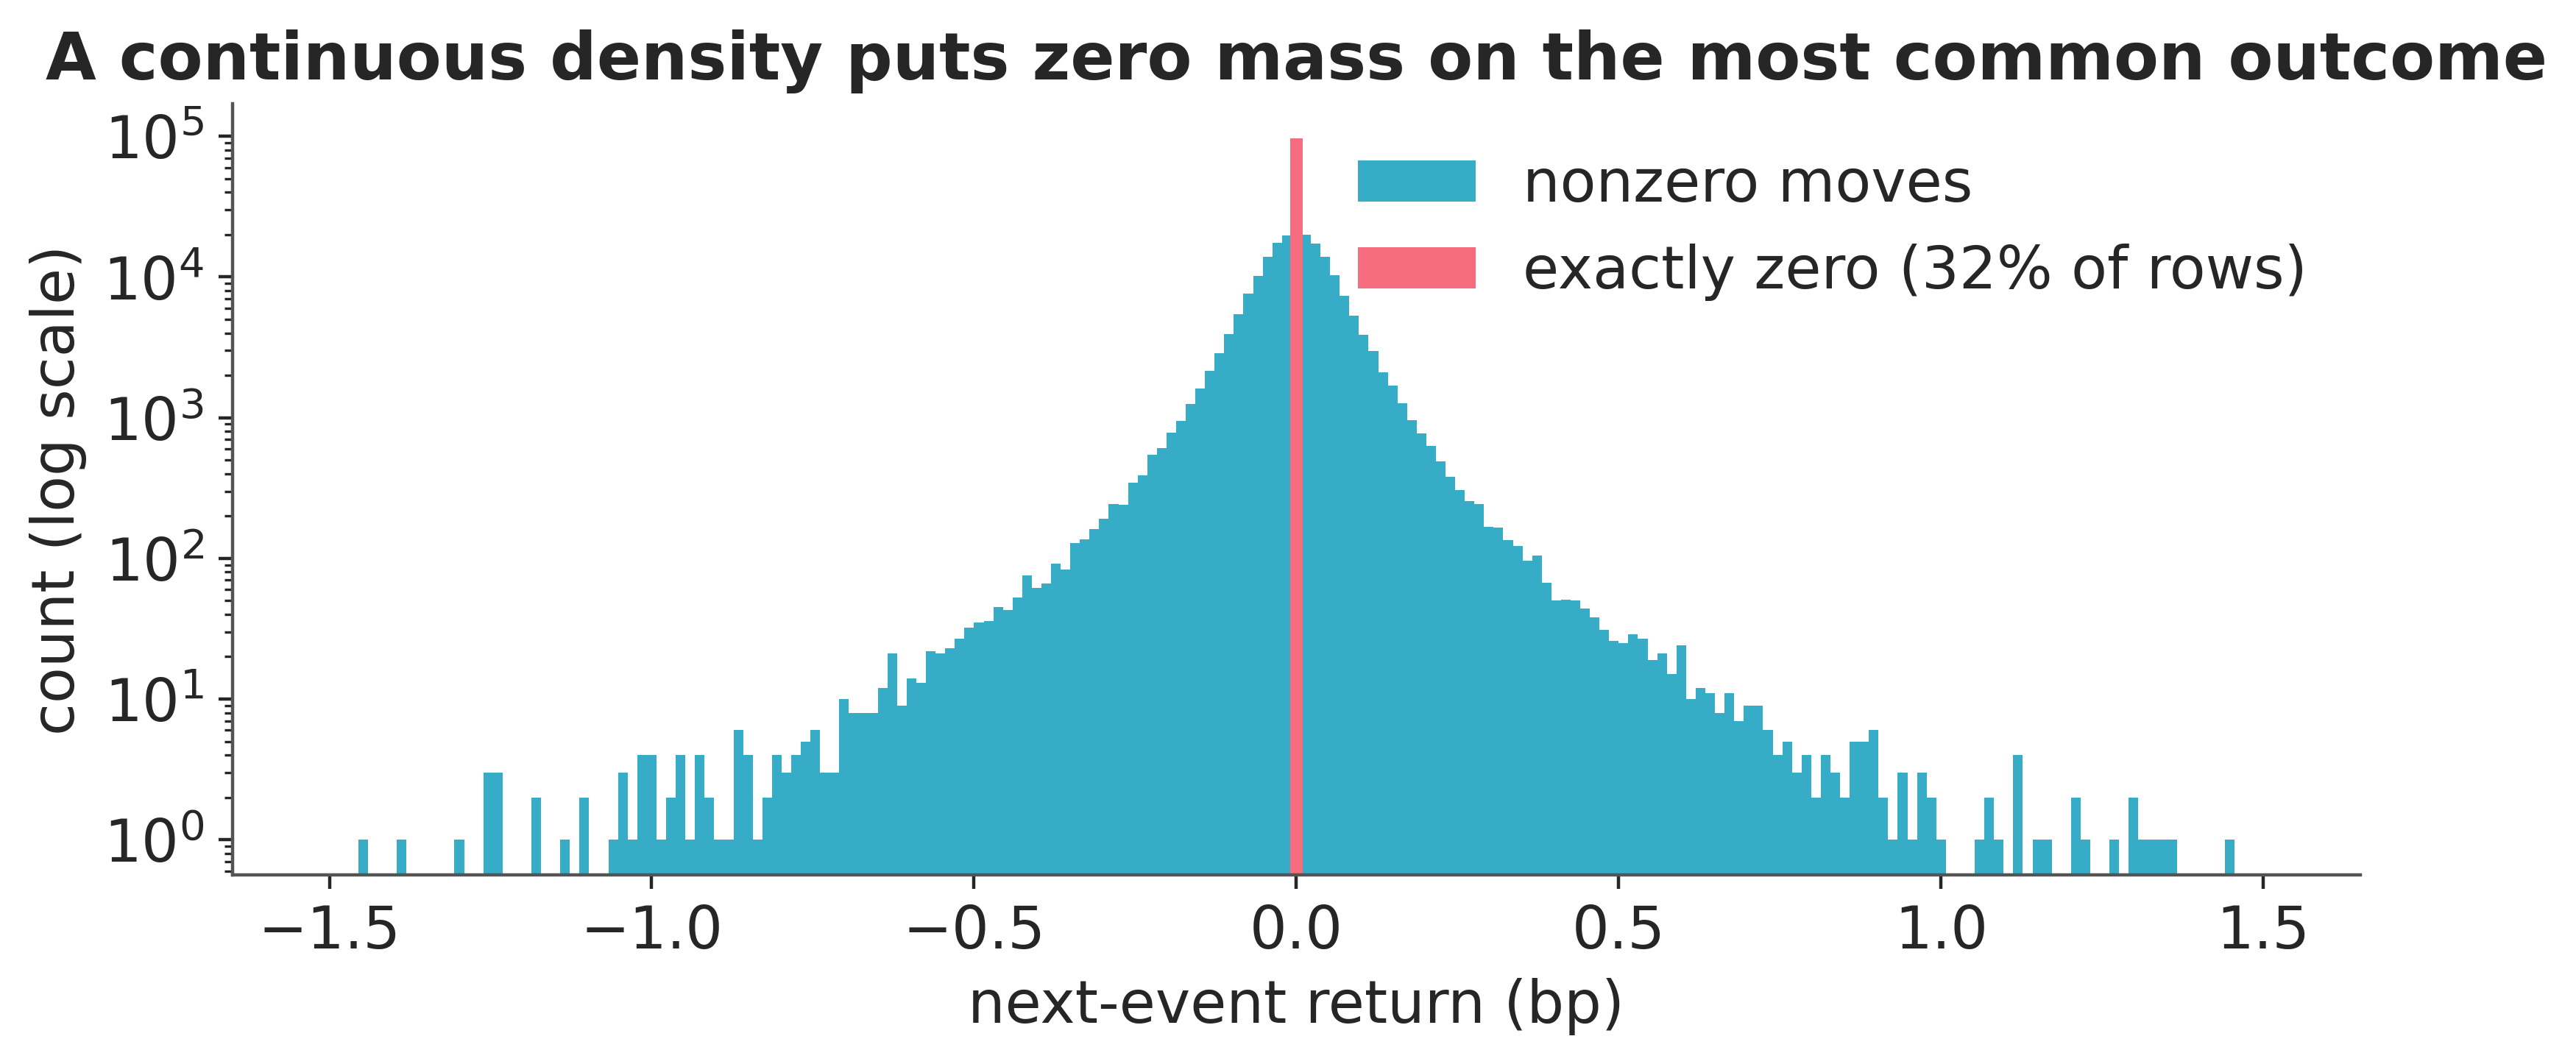

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5), layout="constrained")
moves = y[m == 1]
ax.hist(moves, bins=201, range=(-1.5, 1.5), log=True, color="C0", label="nonzero moves")
ax.bar(
    [0.0],
    [(m == 0).sum()],
    width=0.02,
    color="C1",
    label=f"exactly zero ({(m == 0).mean():.0%} of rows)",
)
ax.set_xlabel("next-event return (bp)")
ax.set_ylabel("count (log scale)")
ax.set_title("A continuous density puts zero mass on the most common outcome")
ax.legend();

## The on-disk global shuffle

The trap in streaming ordered data is subtle enough to deserve its own
section. A bounded runtime shuffle buffer only *block*-shuffles a strongly
ordered stream: with tick data sorted by symbol and time, early optimization
steps would only ever see early dates and the first symbols, and an early
stopping decision would be biased by construction. The fix is to shuffle
**once, globally, on disk at ETL time**: every row gets a deterministic hash
key, rows are scattered across shards by that key, and each shard is sorted by
it. After that, sequential reads follow one fixed, data-independent uniform
permutation — replayed identically each epoch, which is single-shuffle SGD
semantics rather than fresh per-step subsampling — and the loader can run
with `shuffle=False` at full speed.

In [6]:
data_dir = tempfile.mkdtemp(prefix="ticks_")
table = pa.table(
    {
        "y_bp": y.astype(np.float32),
        "m": m,
        "d": d.astype(np.int8),
        "q_std": q.astype(np.float32),
        "a_std": a.astype(np.float32),
        "ylag_bp": ylag.astype(np.float32),
        "hour": hour.astype(np.int8),
        "sym": sym.astype(np.int16),
    }
)


def splitmix64(x):
    x = (x + np.uint64(0x9E3779B97F4A7C15)) & np.uint64(0xFFFFFFFFFFFFFFFF)
    x = ((x ^ (x >> np.uint64(30))) * np.uint64(0xBF58476D1CE4E5B9)) & np.uint64(0xFFFFFFFFFFFFFFFF)
    x = ((x ^ (x >> np.uint64(27))) * np.uint64(0x94D049BB133111EB)) & np.uint64(0xFFFFFFFFFFFFFFFF)
    return x ^ (x >> np.uint64(31))


key = splitmix64(np.arange(n, dtype=np.uint64))
order = np.argsort(key, kind="stable")
n_shards = 8
for i in range(n_shards):
    part = table.take(order[i::n_shards])
    # Row groups are the loader's batches on the shuffle=False path, so size them here.
    pq.write_table(part, os.path.join(data_dir, f"shard_{i:03d}.parquet"), row_group_size=1024)

head = pq.read_table(os.path.join(data_dir, "shard_000.parquet")).slice(0, 10_000)
print(
    f"first 10k rows of one shard cover {len(np.unique(head['hour']))} hours "
    f"and {len(np.unique(head['sym']))} symbols"
)

first 10k rows of one shard cover 24 hours and 12 symbols


On the real corpus the same check is part of the ETL script's validation: the
head of any shard must already mix all 24 hours and nearly all symbols —
asserted on a sampled shard at build time and spot-checked on others, rather
than assumed. Note that the cell above is the pedagogical miniature — it sorts the
whole table in memory, which at corpus scale would need several gigabytes for
the keys and permutation alone. The published ETL is genuinely out-of-core:
pass one hash-scatters rows into shards with bounded row-group appends, pass
two sorts each shard independently, and no step ever holds the corpus.

## Streaming the model

With `shuffle=False` the `DataLoader` passes source blocks through verbatim —
one block per Parquet row group, in a frozen column order — which is why the
shards were written with `row_group_size=1024` above. The dataset size comes
from the Parquet metadata: `loader.total_size` is `N`, and `len(loader)` is
the number of batches per epoch, as for a torch dataloader. The model reads
one `pm.Data` placeholder; everything derived — the Fourier basis, the
integer symbol index — is computed inside the graph, so advancing the stream
is a single `set_value` per step.

In [7]:
columns = ["y_bp", "m", "d", "q_std", "a_std", "ylag_bp", "hour", "sym"]
loader = DataLoader(
    parquet_source(data_dir, columns=columns),
    batch_size=1024,
    shuffle=False,  # the shards are already globally shuffled on disk
    total_size="auto",
)
print(f"N = {loader.total_size:,} rows -> {len(loader):,} batches per epoch")

N = 300,000 rows -> 292 batches per epoch


One deliberate loader semantics to be precise about: on this path nothing is
dropped. Verbatim pass-through streams every row, and the last row group of
each shard is simply shorter than 1024. The `total_size` rescaling copes,
because PyMC scales the minibatch log-likelihood by `N / b` with `b` read
from the batch actually installed, so a short block is weighted up by exactly
its own size. Gate 1's equal-inclusion clause therefore holds for the full
corpus, with no tempering correction to track. (Only the shuffle-buffer path
drops a trailing partial batch; this notebook never uses it.)

In [8]:
def build_model(symbols, batch_init, total_size):
    coords = {"symbol": list(symbols), "harmonic": ["sin1", "cos1", "sin2", "cos2"]}
    with pm.Model(coords=coords) as model:
        batch = pm.Data("batch", batch_init)
        y_ = batch[:, 0]
        d_ = batch[:, 2]
        q_ = batch[:, 3]
        a_ = batch[:, 4]
        ylag_ = batch[:, 5]
        w = 2.0 * np.pi * batch[:, 6] / 24.0
        B_ = pt.stack([pt.sin(w), pt.cos(w), pt.sin(2 * w), pt.cos(2 * w)], axis=1)
        sym_ = pt.cast(batch[:, 7], "int32")

        kappa0 = pm.Normal("kappa0", 0.0, 5.0)
        c = pm.Normal("c", 0.0, 0.5, dims="harmonic")
        lambda_a = pm.Normal("lambda_a", 0.0, 0.5)
        lambda_q = pm.Normal("lambda_q", 0.0, 0.5)

        alpha0 = pm.Normal("alpha0", 0.0, 5.0)
        g = pm.Normal("g", 0.0, 0.3, dims="harmonic")
        beta_a = pm.Normal("beta_a", 0.0, 0.3)
        beta_q = pm.Normal("beta_q", 0.0, 0.3)

        theta_d = pm.Normal("theta_d", 0.0, 0.25)
        theta_r = pm.Normal("theta_r", 0.0, 0.25)

        tau_k, tau_ph, tau_al, tau_sh, tau_ba = (
            pm.LogNormal(name, 0.0, 1.5)
            for name in ["tau_k", "tau_ph", "tau_al", "tau_sh", "tau_ba"]
        )
        b_k = pm.Normal("b_k", 0.0, tau_k, dims="symbol")
        b_ph = pm.Normal("b_ph", 0.0, tau_ph, dims=("symbol", "harmonic"))
        b_al = pm.Normal("b_al", 0.0, tau_al, dims="symbol")
        b_sh = pm.Normal("b_sh", 0.0, tau_sh, dims=("symbol", "harmonic"))
        b_ba = pm.Normal("b_ba", 0.0, tau_ba, dims="symbol")

        eta = pm.Normal("eta", 5.0, 1.0)
        nu = pm.Deterministic("nu", 1.0 + pt.softplus(eta))

        logit_pi = (
            kappa0
            + b_k[sym_]
            + (B_ * (c + b_ph[sym_])).sum(axis=-1)
            + lambda_a * a_
            + lambda_q * q_
        )
        log_sigma = (
            alpha0
            + b_al[sym_]
            + (B_ * (g + b_sh[sym_])).sum(axis=-1)
            + (beta_a + b_ba[sym_]) * a_
            + beta_q * q_
        )
        mu = theta_d * d_ + theta_r * ylag_

        def hurdle_logp(value, logit_pi, mu, log_sigma, nu):
            # one coherent mixed distribution: an atom at exactly zero plus a
            # Student-t density off zero — the move indicator is value != 0,
            # never a separate parameter, so logp and random describe the SAME law
            sigma = pt.exp(log_sigma)
            t_ll = (
                pt.gammaln((nu + 1.0) / 2.0)
                - pt.gammaln(nu / 2.0)
                - 0.5 * pt.log(nu * np.pi)
                - log_sigma
                - (nu + 1.0) / 2.0 * pt.log1p(((value - mu) / sigma) ** 2 / nu)
            )
            moved = pt.neq(value, 0.0)
            return pt.where(moved, -pt.softplus(-logit_pi) + t_ll, -pt.softplus(logit_pi))

        def hurdle_random(logit_pi, mu, log_sigma, nu, rng=None, size=None):
            # simulate the same law: first whether the price moves, then how far
            pi = 1.0 / (1.0 + np.exp(-logit_pi))
            move = rng.random(size=size) < pi
            draw = mu + np.exp(log_sigma) * rng.standard_t(nu, size=size)
            return np.where(move, draw, 0.0)

        pm.CustomDist(
            "y_obs",
            logit_pi,
            mu,
            log_sigma,
            nu,
            logp=hurdle_logp,
            random=hurdle_random,
            observed=y_,
            total_size=total_size,
        )
    return model

Two implementation notes worth pausing on. The likelihood is a
{class}`~pymc.CustomDist` with a `logp`, not a `pm.Potential`: `CustomDist`
gives the term *observed-RV semantics*, which is what makes PyMC's own
`total_size` minibatch rescaling apply {cite:p}`kucukelbir2015automatic`. And
the hurdle's two logs are written with `softplus` —
$\log \pi = -\operatorname{softplus}(-x)$,
$\log(1-\pi) = -\operatorname{softplus}(x)$ — which is exact and stable at both
tails. The exact float comparison `value != 0` is safe here because the zeros
are *structural* — a transition either changes the price or it does not, and
the smallest genuine move on any listed tick grid sits dozens of orders of
magnitude above the float32 flush-to-zero threshold.

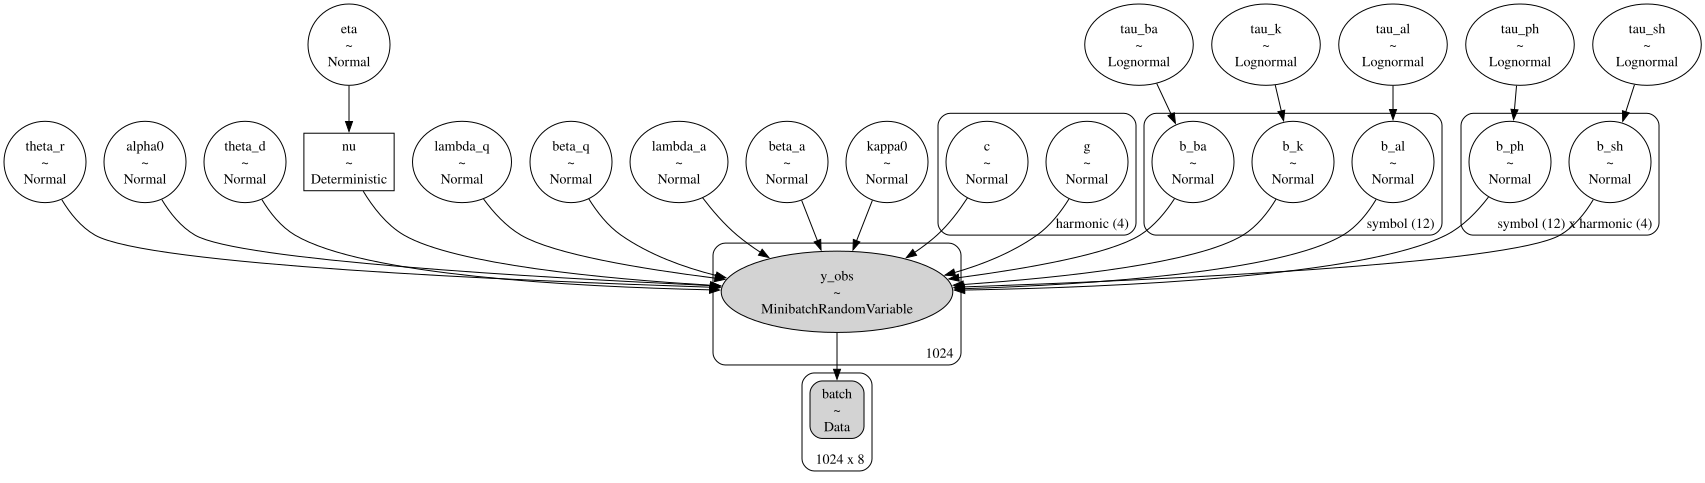

In [9]:
model = build_model(
    [f"SYM{i:02d}" for i in range(n_symbols)], next(iter(loader)), loader.total_size
)
pm.model_to_graphviz(model)

The plate diagram makes the two-link structure visible at a glance: five
partially pooled effect families on the symbol plate feeding two linear
predictors, one shared tail parameter, and a single observed node whose batch
dimension is whatever the placeholder currently holds.

In [10]:
class StreamAdvance:
    """pm.fit callback: put the next minibatch into the placeholder after each step."""

    def __init__(self, model, loader):
        self._shared = model["batch"]
        self._stream = self._endless(loader)

    @staticmethod
    def _endless(loader):
        while True:
            yield from loader

    def prime(self):
        self._shared.set_value(next(self._stream), borrow=True)

    def __call__(self, approx, losses, i):
        self._shared.set_value(next(self._stream), borrow=True)


stream = StreamAdvance(model, loader)
stream.prime()

with model:
    advi = pm.ADVI(random_seed=RANDOM_SEED)
advi.fit(6_000, obj_optimizer=pm.adam(learning_rate=0.02), callbacks=[stream], progressbar=False)
approx = advi.fit(
    2_500, obj_optimizer=pm.adam(learning_rate=0.005), callbacks=[stream], progressbar=False
)

The two-stage learning rate is not decoration: at a constant 0.02 the Adam
updates near the optimum are larger than the posterior standard deviations of
the sharpest parameters, so the mean jitters around the mode instead of
settling into it. Annealing was adopted after measuring exactly that on the
prototype.

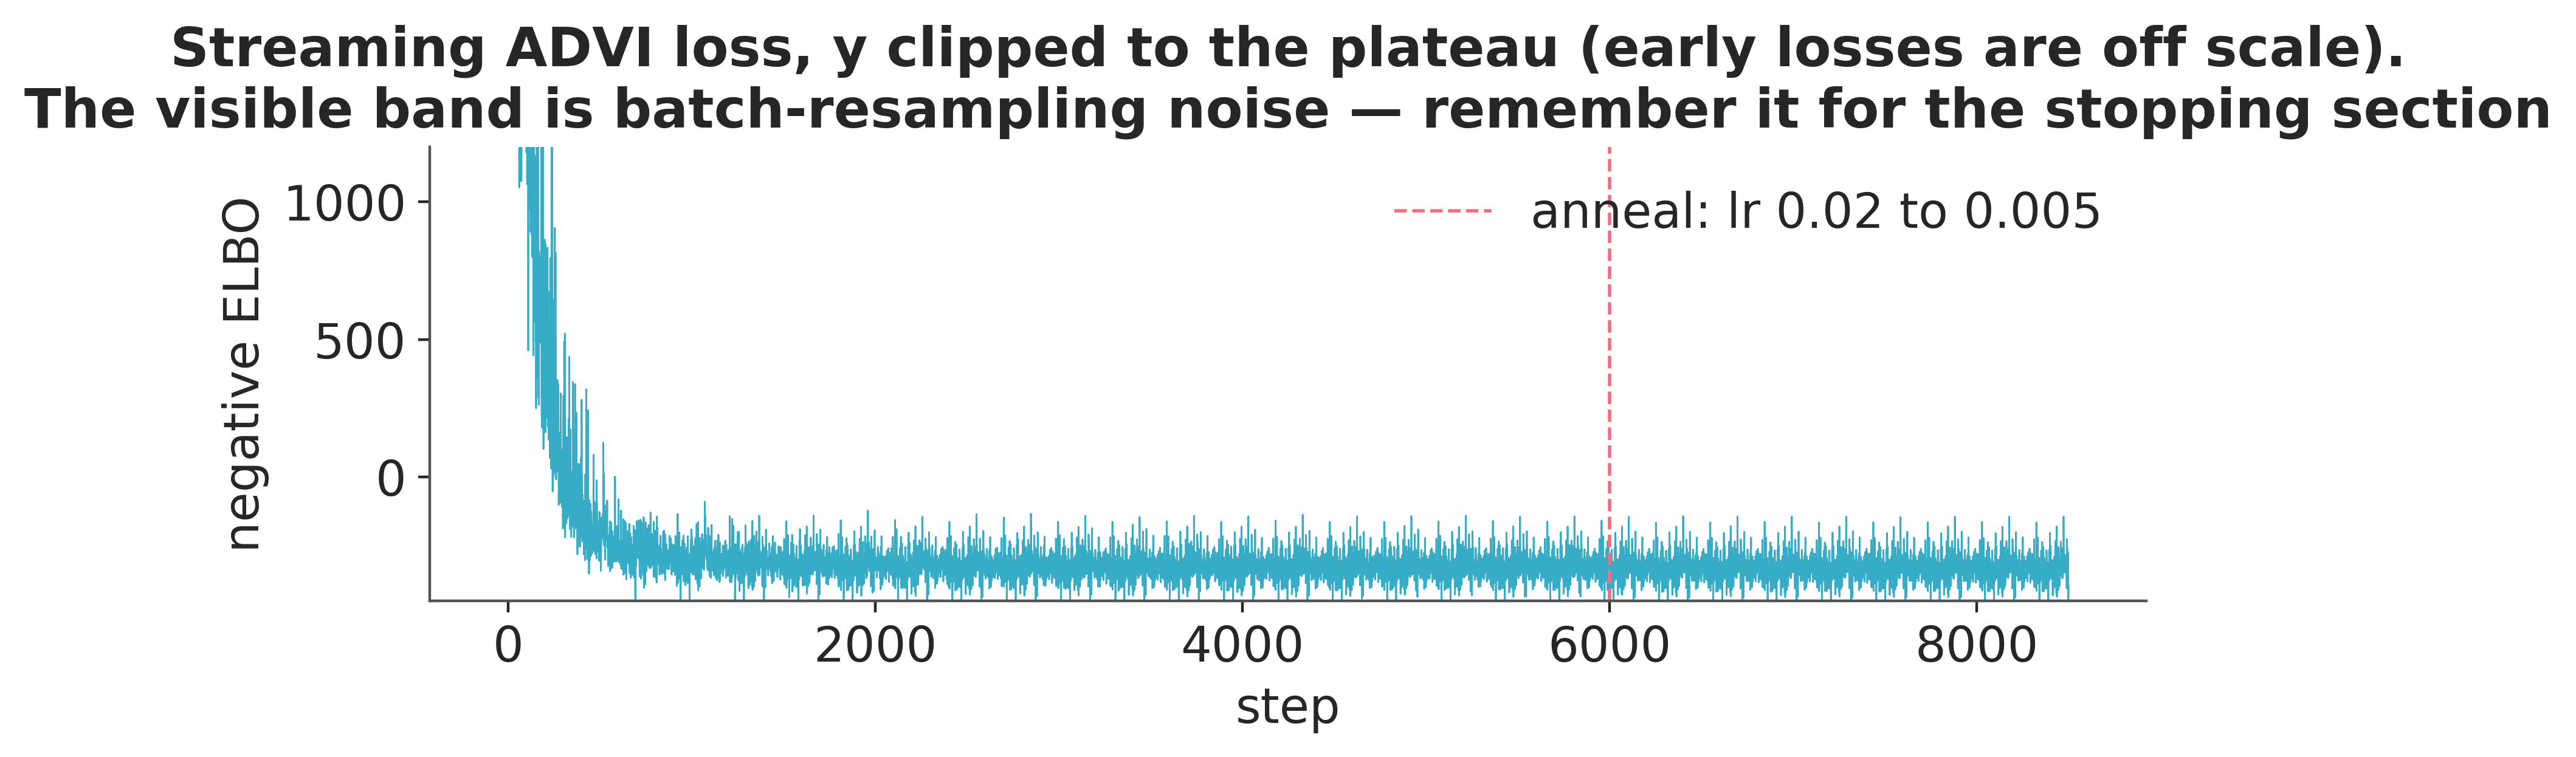

In [11]:
fig, ax = plt.subplots(figsize=(8, 3), layout="constrained")
ax.plot(approx.hist, lw=0.5)
ax.axvline(6_000, color="C1", ls="--", lw=1, label="anneal: lr 0.02 to 0.005")
ax.set_ylim(-450, 1200)
ax.set_xlabel("step")
ax.set_ylabel("negative ELBO")
ax.set_title(
    "Streaming ADVI loss, y clipped to the plateau (early losses are "
    "off scale).\nThe visible band is batch-resampling noise — "
    "remember it for the stopping section"
)
ax.legend();

## Did it recover the truth?

In [12]:
idata = approx.sample(2_000, random_seed=RANDOM_SEED)
post = idata.posterior

scalar_params = [
    "kappa0",
    "alpha0",
    "lambda_a",
    "lambda_q",
    "beta_a",
    "beta_q",
    "theta_d",
    "theta_r",
    "nu",
]
rows = {name: [float(post[name].mean()), float(post[name].std())] for name in scalar_params}
# the intercepts share a ridge with their group means; only the sums are identified
for icpt, b in [("kappa0", "b_k"), ("alpha0", "b_al"), ("beta_a", "b_ba")]:
    s = post[icpt] + post[b].mean("symbol")
    rows[f"{icpt} + mean({b})"] = [float(s.mean()), float(s.std())]
recovery = pd.DataFrame(rows, index=["mean", "sd"]).T
recovery["truth"] = [truth[p] for p in scalar_params] + [
    truth["kappa0"],
    truth["alpha0"],
    truth["beta_a"],
]
recovery["abs_error"] = (recovery["mean"] - recovery["truth"]).abs()
recovery.round(4)

,mean,sd,truth,abs_error
kappa0,0.5299,0.0052,0.8473,0.3174
alpha0,-1.6986,0.0036,-2.9957,1.2972
lambda_a,0.3384,0.0050,0.3500,0.0116
lambda_q,0.2094,0.0047,0.2000,0.0094
beta_a,0.1733,0.0030,0.1800,0.0067
beta_q,0.1435,0.0032,0.1200,0.0235
theta_d,0.0213,0.0002,0.0200,0.0013
theta_r,0.2505,0.0012,0.2500,0.0005
nu,3.5092,0.0249,3.5000,0.0092
kappa0 + mean(b_k),0.8299,0.0113,0.8473,0.0174


Read the table bottom-up. The raw intercepts look off by 0.3 and 1.3 — but a
global coefficient and the mean of its group effects are only *jointly*
identified: the likelihood constrains their sum, and the prior only weakly
splits it. The identified sums in the last three rows land within about one
hundredth of the truth, comparable to the other likelihood-identified rows.
The same translation ridge exists for every global-coefficient/group-effect
pair in this model (including the vector pairs $c$/$b^{(\pi h)}$ and
$g$/$b^{(\sigma h)}$, whose sums we spare you) — so raw split rows like
`kappa0`, `alpha0`, and `beta_a` are prior-dependent decompositions, not
estimates of their generating values; a sum-to-zero constraint on the symbol
effects is the standard reparameterization when the split itself matters.
Notice also what we did *not* print: z-scores against the truth. Some would
exceed 2, because the mean-field standard deviations in the third column are
razor-thin — a z-score against a point truth mixes the sampling noise of this
particular synthetic dataset with variational overconfidence along exactly
such ridges. This is the first appearance of a theme the notebook returns to
at full scale: a mean-field width is usable only where seed replication has
failed to disqualify it — replication can veto a width, never certify one.

The more interesting check is hierarchical: what happened to the per-symbol
effects of the two symbols with 1,800 and 900 rows?

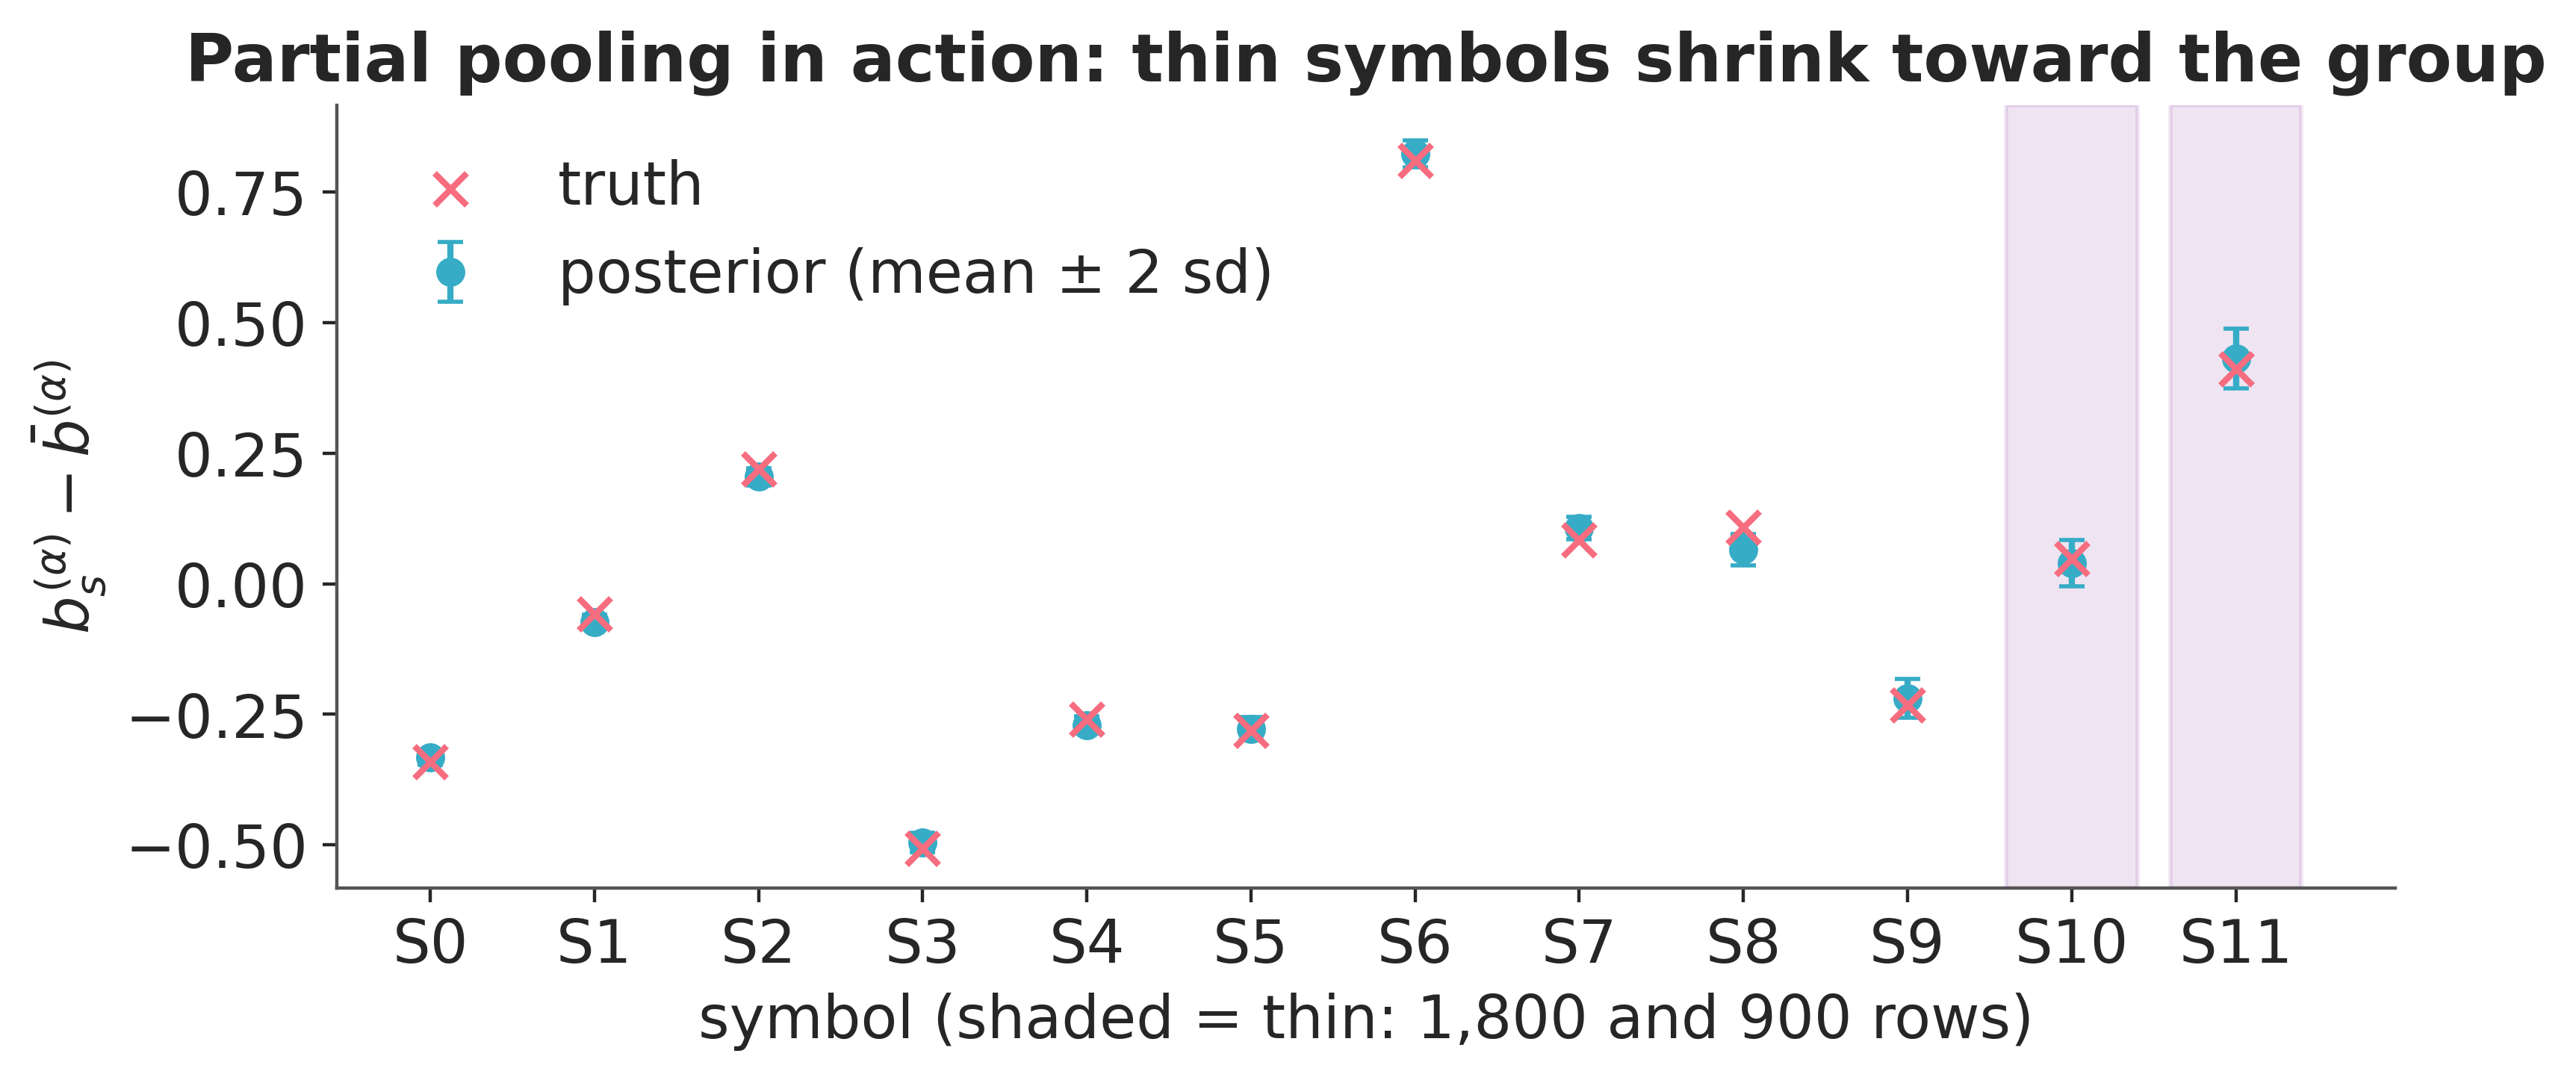

In [13]:
# plot the identified CONTRAST b - mean(b): the table above showed the absolute
# level belongs to a ridge with the intercept, so comparing raw b to raw truth
# would only display the arbitrary level split. Hand-rolled rather than
# az.plot_forest because the display is bespoke: truth overlay + thin shading.
bc = post["b_al"] - post["b_al"].mean("symbol")
b_mean = bc.mean(("chain", "draw")).values
b_sd = bc.std(("chain", "draw")).values
b_truth = 0.35 * z_truth["z_al"]  # the generator's scale times its z draws
b_truth = b_truth - b_truth.mean()

fig, ax = plt.subplots(figsize=(8, 3.5), layout="constrained")
x = np.arange(n_symbols)
ax.errorbar(
    x, b_mean, yerr=2 * b_sd, fmt="o", color="C0", capsize=3, label="posterior (mean ± 2 sd)"
)
ax.scatter(x, b_truth, marker="x", color="C1", s=60, zorder=3, label="truth")
for t in thin:
    ax.axvspan(t - 0.4, t + 0.4, color="C3", alpha=0.12)
ax.set_xticks(x)
ax.set_xticklabels([f"S{i}" for i in x])
ax.set_xlabel("symbol (shaded = thin: 1,800 and 900 rows)")
ax.set_ylabel(r"$b^{(\alpha)}_s - \bar{b}^{(\alpha)}$")
ax.set_title("Partial pooling in action: thin symbols shrink toward the group")
ax.legend();

The thin symbols' estimates are pulled toward zero and carry visibly wider
intervals — that is partial pooling doing exactly what it is for
{cite:p}`gelman2006data`. On the real corpus, where the thinnest symbol has
67,000 rows against BTC's 203 million, the same mechanism is what makes the
tail of the symbol universe estimable at all.

## Does it predict what matters?

A recovery table checks parameters; a posterior predictive check asks the
model to reproduce the data features it exists to describe. The `CustomDist`
carries a `random` implementation alongside its `logp`, so
{func}`~pymc.sample_posterior_predictive` works out of the box. The two
features that matter for this model are the exact-zero share and the heavy
conditional tail:

In [14]:
eval_batch = next(iter(loader))
model["batch"].set_value(eval_batch, borrow=True)  # same path the callback uses
with model:
    idata = pm.sample_posterior_predictive(
        idata,
        var_names=["y_obs"],
        random_seed=RANDOM_SEED,
        extend_inferencedata=True,
        progressbar=False,
    )

pp = idata.posterior_predictive["y_obs"].stack(sample=("chain", "draw")).values.T
y_eval = eval_batch[:, 0]

zero_share = (pp == 0).mean(axis=1)
med_nonzero = np.array([np.median(np.abs(d[d != 0])) for d in pp[:500]])
q99_nonzero = np.array([np.quantile(np.abs(d[d != 0]), 0.99) for d in pp[:500]])


def check_row(observed, draws):
    lo, hi = np.quantile(draws, [0.05, 0.95])
    return [observed, draws.mean(), lo, hi]


y_nonzero = np.abs(y_eval[y_eval != 0])
pd.DataFrame(
    [
        check_row((y_eval == 0).mean(), zero_share),
        check_row(np.median(y_nonzero), med_nonzero),
        check_row(np.quantile(y_nonzero, 0.99), q99_nonzero),
    ],
    columns=["observed", "pp mean", "pp 5%", "pp 95%"],
    index=["zero share", "median |move| (bp)", "q99 |move| (bp)"],
).round(3)

,observed,pp mean,pp 5%,pp 95%
zero share,0.315,0.331,0.308,0.355
median |move| (bp),0.042,0.041,0.038,0.044
q99 |move| (bp),0.324,0.340,0.281,0.411


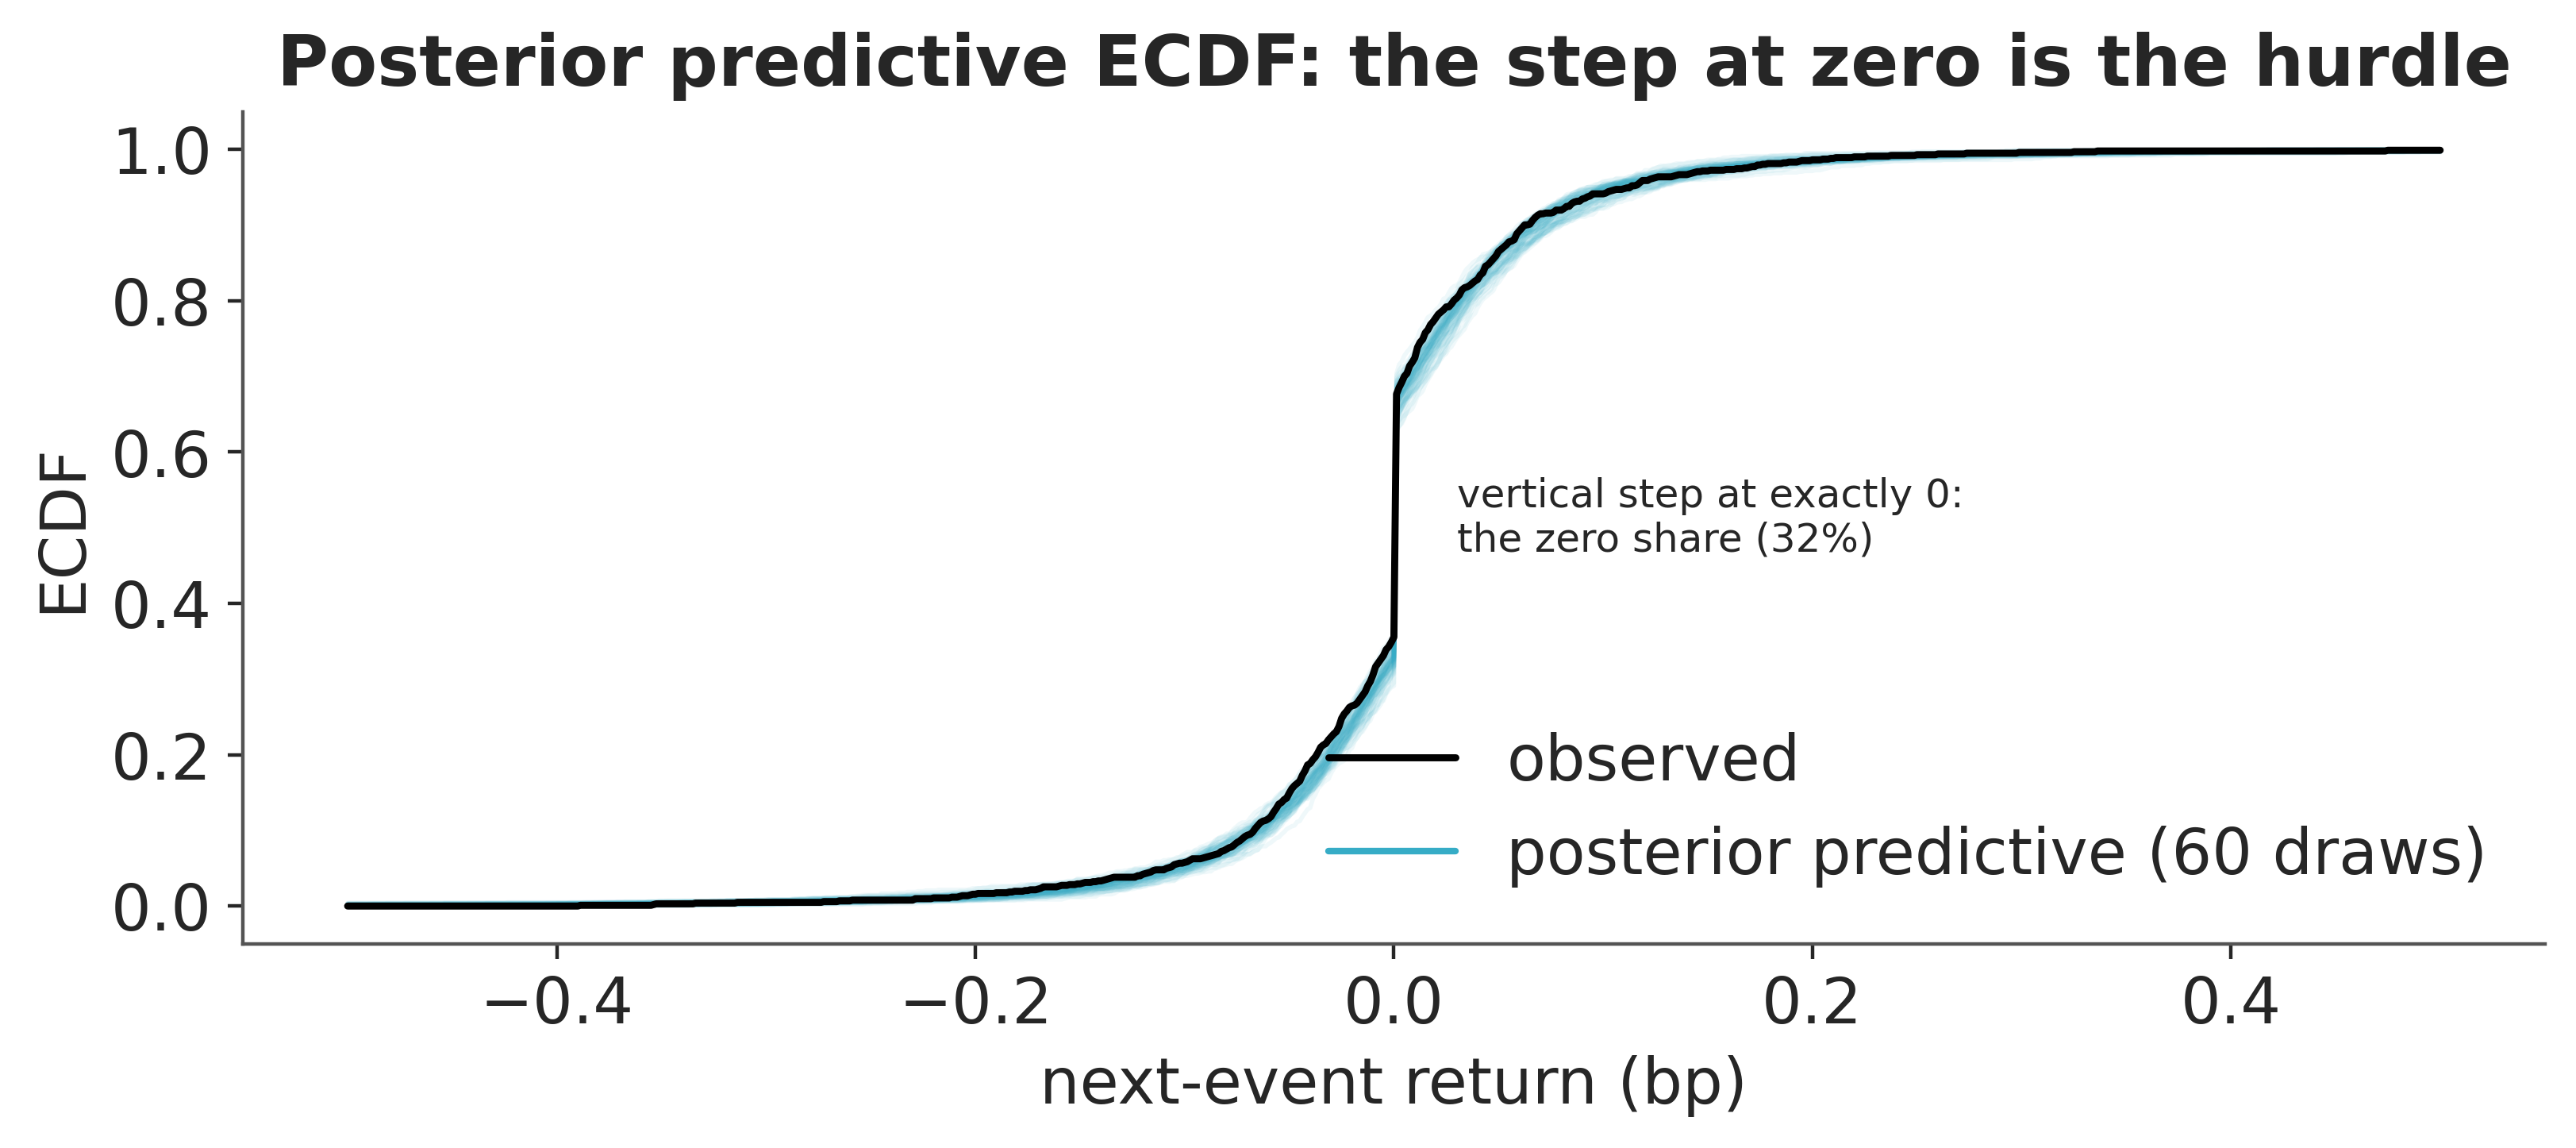

In [15]:
# hand-rolled ECDF: the bespoke feature is the annotated discrete jump at zero,
# which the predictive must reproduce in both location and height
fig, ax = plt.subplots(figsize=(8, 3.5), layout="constrained")
grid = np.linspace(-0.5, 0.5, 801)
for draw in pp[:60]:
    ax.plot(grid, np.searchsorted(np.sort(draw), grid) / draw.size, color="C0", alpha=0.08, lw=1)
ax.plot(
    grid, np.searchsorted(np.sort(y_eval), grid) / y_eval.size, color="k", lw=1.6, label="observed"
)
ax.plot([], [], color="C0", label="posterior predictive (60 draws)")
zero_jump = (y_eval == 0).mean()
below = (y_eval < 0).mean()
ax.annotate(
    f"vertical step at exactly 0:\nthe zero share ({zero_jump:.0%})",
    (0.03, below + zero_jump / 2),
    fontsize=9,
    ha="left",
    va="center",
)
ax.set_xlabel("next-event return (bp)")
ax.set_ylabel("ECDF")
ax.set_title("Posterior predictive ECDF: the step at zero is the hurdle")
ax.legend(loc="lower right");

Two of the three statistics sit inside their predictive 90% bands; the median
|move| lands at the band's edge (0.8% outside at full precision — the
3-decimal table hides it, so we say it here). Note also that this is an
in-sample adequacy check: the evaluation batch was seen during the fit; the
real-corpus scores later use shards the fits never touched. On real data one
further caveat would surface
here that the synthetic generator cannot show: real price changes are integer
multiples of the tick size, so the continuous Student-t's residual misfit
concentrates at |y| near one tick — visible as small stair-steps in the
observed ECDF that the smooth predictive cannot follow.

## Knowing when to stop — and how a stop rule can lie to you

A streamed ELBO trace is noisy — each value is a one-batch, one-Monte-Carlo
estimate — and eyeballing it does not scale to overnight runs. The stopping
rule originally proposed for PyMC in
[pymc#8384](https://github.com/pymc-devs/pymc/pull/8384)
standardizes each loss *improvement* by a robust running scale estimate and
feeds it to a one-sided CUSUM statistic {cite:p}`page1954continuous`, arming
itself only after `min_steps` — which on streaming fits should be at least
one full pass, since stopping before the model has seen every row once is
never evidence of convergence. The trap this section demonstrates was later
confirmed on real ADVI traces, and the revised implementation under review
for `pymc-extras` is built on the windowed idea shown here, with horizons
that grow over the run and a second, practical-negligibility yardstick.

:::{admonition} The minibatch trap
:class: warning
Successive losses are evaluated on *different batches*, so the per-step noise
dwarfs the per-step improvement: on our full-scale run the median one-step
change is about 106 loss units while the mean improvement — (first − last)
loss over the run's steps — is about 0.06 units per step. A rule that standardizes *raw* increments concludes "improvement is
indistinguishable from zero" immediately upon arming, and fires a fixed
~$h/\kappa$ steps later regardless of whether the fit converged.
:::

The fix is as small as the trap is subtle: apply the identical rule to
*window means* of the loss, where averaging beats the batch-resampling noise
down by $\sqrt{k}$ and real improvement becomes visible again. We run both
against the same fit, as non-fatal shadow observers, and let them disagree:

In [16]:
class CheckLossConvergence:
    """One-sided CUSUM on robustly standardized loss improvements (pymc#8384)."""

    def __init__(self, kappa=0.25, h=20.0, halflife=200.0, min_steps=1000, z_clip=4.0):
        self.kappa, self.h, self.halflife = kappa, h, halflife
        self.min_steps, self.z_clip = min_steps, z_clip
        self._lam = float(np.exp(np.log(0.5) / halflife))
        self._prev_loss = self._prev_delta = self._scale = None
        self._S = 0.0

    def __call__(self, approx, loss, i):
        current = float(loss[-1])
        if not np.isfinite(current):
            return
        if self._prev_loss is None:
            self._prev_loss = current
            return
        delta, self._prev_loss = self._prev_loss - current, current
        if self._prev_delta is None:
            self._prev_delta = delta
            return
        abs_diff, self._prev_delta = abs(delta - self._prev_delta), delta
        if self._scale is None:
            self._scale = abs_diff
            return
        sigma = self._scale * np.sqrt(np.pi) / 2.0 + 1e-12
        self._scale = self._lam * self._scale + (1.0 - self._lam) * abs_diff
        z = float(np.clip(delta / sigma, -self.z_clip, self.z_clip))
        if i >= self.min_steps:
            self._S = max(0.0, self._S + (self.kappa - z))
        if self._S > self.h:
            raise StopIteration(f"converged at step {i} (S={self._S:.1f})")

In [17]:
class WindowMean:
    """Feed a stop rule the mean of every k losses instead of raw increments."""

    def __init__(self, monitor, k):
        self.monitor, self.k = monitor, k
        self._means = []

    def __call__(self, approx, losses, i):
        if len(losses) % self.k:
            return
        self._means.append(np.mean(losses[-self.k :]))
        self.monitor(approx, self._means, len(self._means))


class Shadow:
    """Record where a stop rule WOULD fire, without actually stopping the fit."""

    def __init__(self, callback):
        self.callback, self.stopped_at = callback, None

    def __call__(self, approx, losses, i):
        if self.stopped_at is None:
            try:
                self.callback(approx, losses, i)
            except StopIteration:
                self.stopped_at = len(losses)

In [18]:
loader2 = DataLoader(
    parquet_source(data_dir, columns=columns),
    batch_size=1024,
    shuffle=False,
    total_size="auto",
)
model2 = build_model(
    [f"SYM{i:02d}" for i in range(n_symbols)], next(iter(loader2)), loader2.total_size
)
stream2 = StreamAdvance(model2, loader2)
stream2.prime()
steps_per_epoch = len(loader2)  # batches per epoch, torch-style

k = 50
min_windows = -(-steps_per_epoch // k)  # ceil: never arm before one full pass
raw_shadow = Shadow(CheckLossConvergence(min_steps=steps_per_epoch))
win_shadow = Shadow(WindowMean(CheckLossConvergence(min_steps=min_windows), k))

with model2:
    advi2 = pm.ADVI(random_seed=RANDOM_SEED)
approx2 = advi2.fit(
    20_000,
    obj_optimizer=pm.adam(learning_rate=0.02),
    callbacks=[stream2, raw_shadow, win_shadow],
    progressbar=False,
)
assert (
    raw_shadow.stopped_at is not None and win_shadow.stopped_at is not None
), "a shadow rule never fired within the 20k-step budget; raise the budget"
win_stop = win_shadow.stopped_at  # Shadow records raw steps for both rules
print(
    f"raw increments: would stop at step {raw_shadow.stopped_at:,} "
    f"(loss there {approx2.hist[raw_shadow.stopped_at]:,.0f})"
)
print(
    f"window means (k={k}): would stop at step {win_stop:,} "
    f"(loss there {approx2.hist[win_stop]:,.0f}, final {approx2.hist[-1]:,.0f})"
)

raw increments: would stop at step 371 (loss there -122)
window means (k=50): would stop at step 4,650 (loss there -442, final -339)


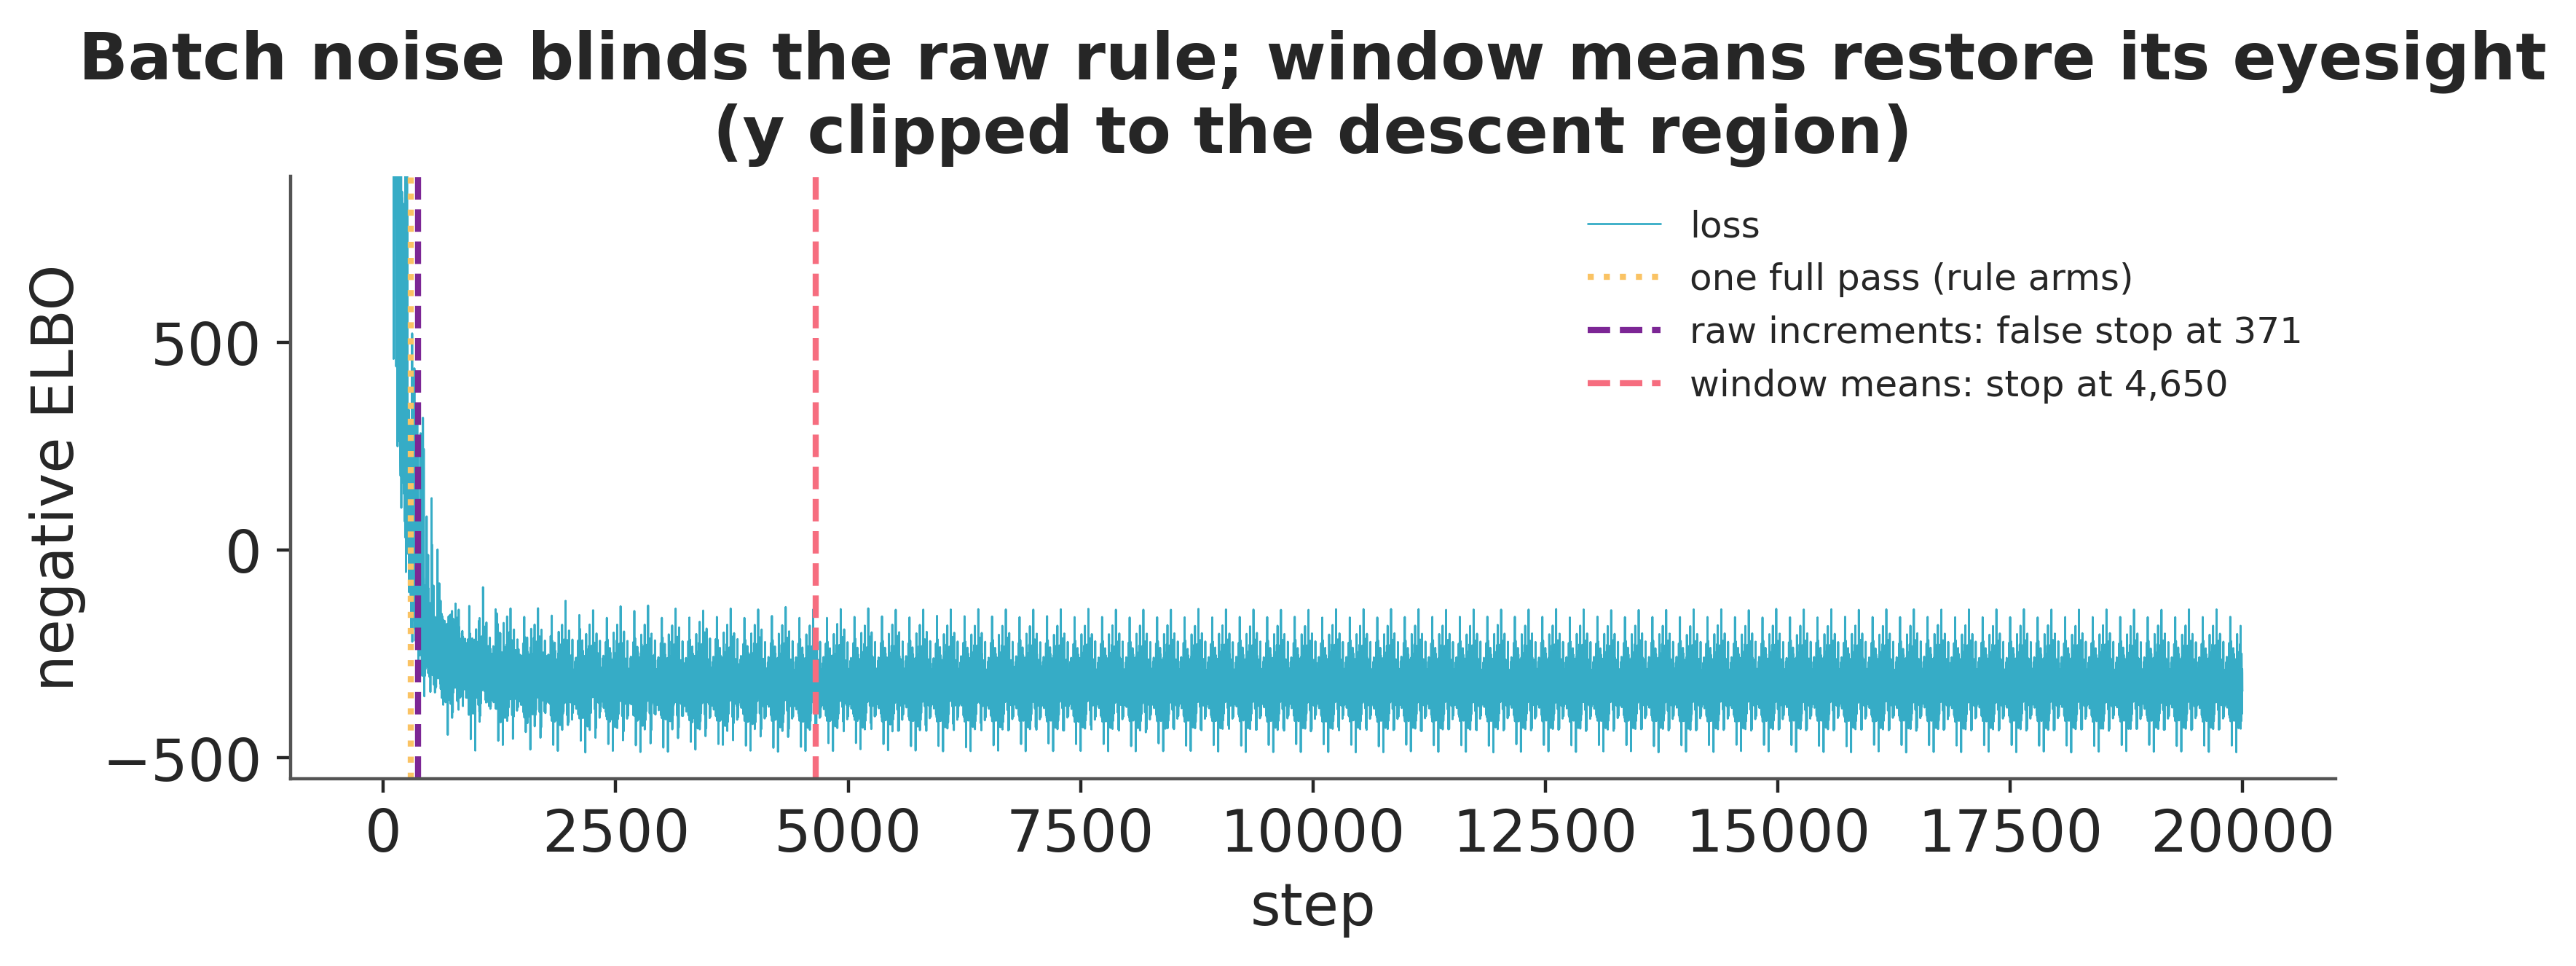

In [19]:
fig, ax = plt.subplots(figsize=(8, 3.2), layout="constrained")
ax.plot(approx2.hist, lw=0.5, label="loss")
ax.axvline(steps_per_epoch, color="C2", ls=":", label="one full pass (rule arms)")
ax.axvline(
    raw_shadow.stopped_at,
    color="C3",
    ls="--",
    label=f"raw increments: false stop at {raw_shadow.stopped_at:,}",
)
ax.axvline(win_stop, color="C1", ls="--", label=f"window means: stop at {win_stop:,}")
ax.set_ylim(-550, 900)
ax.set_xlabel("step")
ax.set_ylabel("negative ELBO")
ax.set_title(
    "Batch noise blinds the raw rule; window means restore its eyesight\n"
    "(y clipped to the descent region)"
)
ax.legend(fontsize=9, loc="upper right");

The raw rule fires a fixed ~80 steps after arming with the loss still far from
its floor — a false stop that a fixed-budget run would silently avoid. The
windowed rule stops once per-window improvement falls below a quarter of the
window-noise scale, here capturing roughly 95% of the total loss descent at
under a quarter of the step budget. Two honest qualifications. First, what the
rule detects is a *loss plateau* — a necessary signal, not a proof that the
posterior has converged; the held-out checks in the next section are the
independent evidence. Second, the $h/\kappa$-window delay after a plateau is
the rule's *nominal* detection lag; clipping and the adaptive scale can move
the actual hitting time. On the full-scale corpus the same replay shows the
windowed rule stopping shortly after one pass, at a *training loss* within
noise of the two-pass reference — whether that stop is also good enough on
held-out score is precisely what the pre-registered test in the next section
failed to confirm.

(tick-real-corpus)=

## The real corpus: 38 symbols, half a billion transitions

Everything above runs identically on real data; what changes is only the ETL
in front of it. The full-scale corpus behind the numbers in this section:

- **Source**: Binance's public aggregated-trades archive
  (`data.binance.vision`) — no API key, published SHA-256 checksums, monthly
  CSV dumps. The corpus is 491,559,069 transition rows: four majors
  (BTC/ETH/SOL/XRP × 6 months of 2026) for row bulk plus 34 alt pairs
  (June 2026) for hierarchy breadth, the thinnest at 67,000 rows.
- **ETL**: per symbol, *chronologically*: next-event returns, move indicator,
  trade sign, standardized log notional, trailing 60-second activity, last
  nonzero return, hour — then the splitmix64 global shuffle into 64 shards
  (~9 GB of Parquet), with the shard-head mixing check asserted. The complete
  script is published with the notebook's companion repository.
- **Hardware**: one Apple M4 laptop, 24 GB RAM. No cluster anywhere.

Fitting the full corpus for two passes (one at lr 0.02, one at 0.005) takes
about four minutes at roughly 1,000 optimization steps per second (4 million
rows per second through the model), with peak resident memory of 1.1 GB for
the whole run — fit loop plus posterior draws and summaries; the memory-wall
figure's leaner 0.5 GB point measures the fit loop alone. Both are flat in N. The subsections below are the
measured results; each figure's numbers are inlined verbatim from the run
logs so the plots execute without any data access.

### The memory wall, measured

Every number in the cells below is inlined verbatim from the run artifacts of
the published scripts, so these figures execute without touching the data.
First, the reason streaming exists at all. Each point is a fresh subprocess's
peak resident memory (`ru_maxrss`) after fitting this exact model at that many
rows — `pm.Minibatch` holding the rows in RAM versus the loader streaming the
shards:

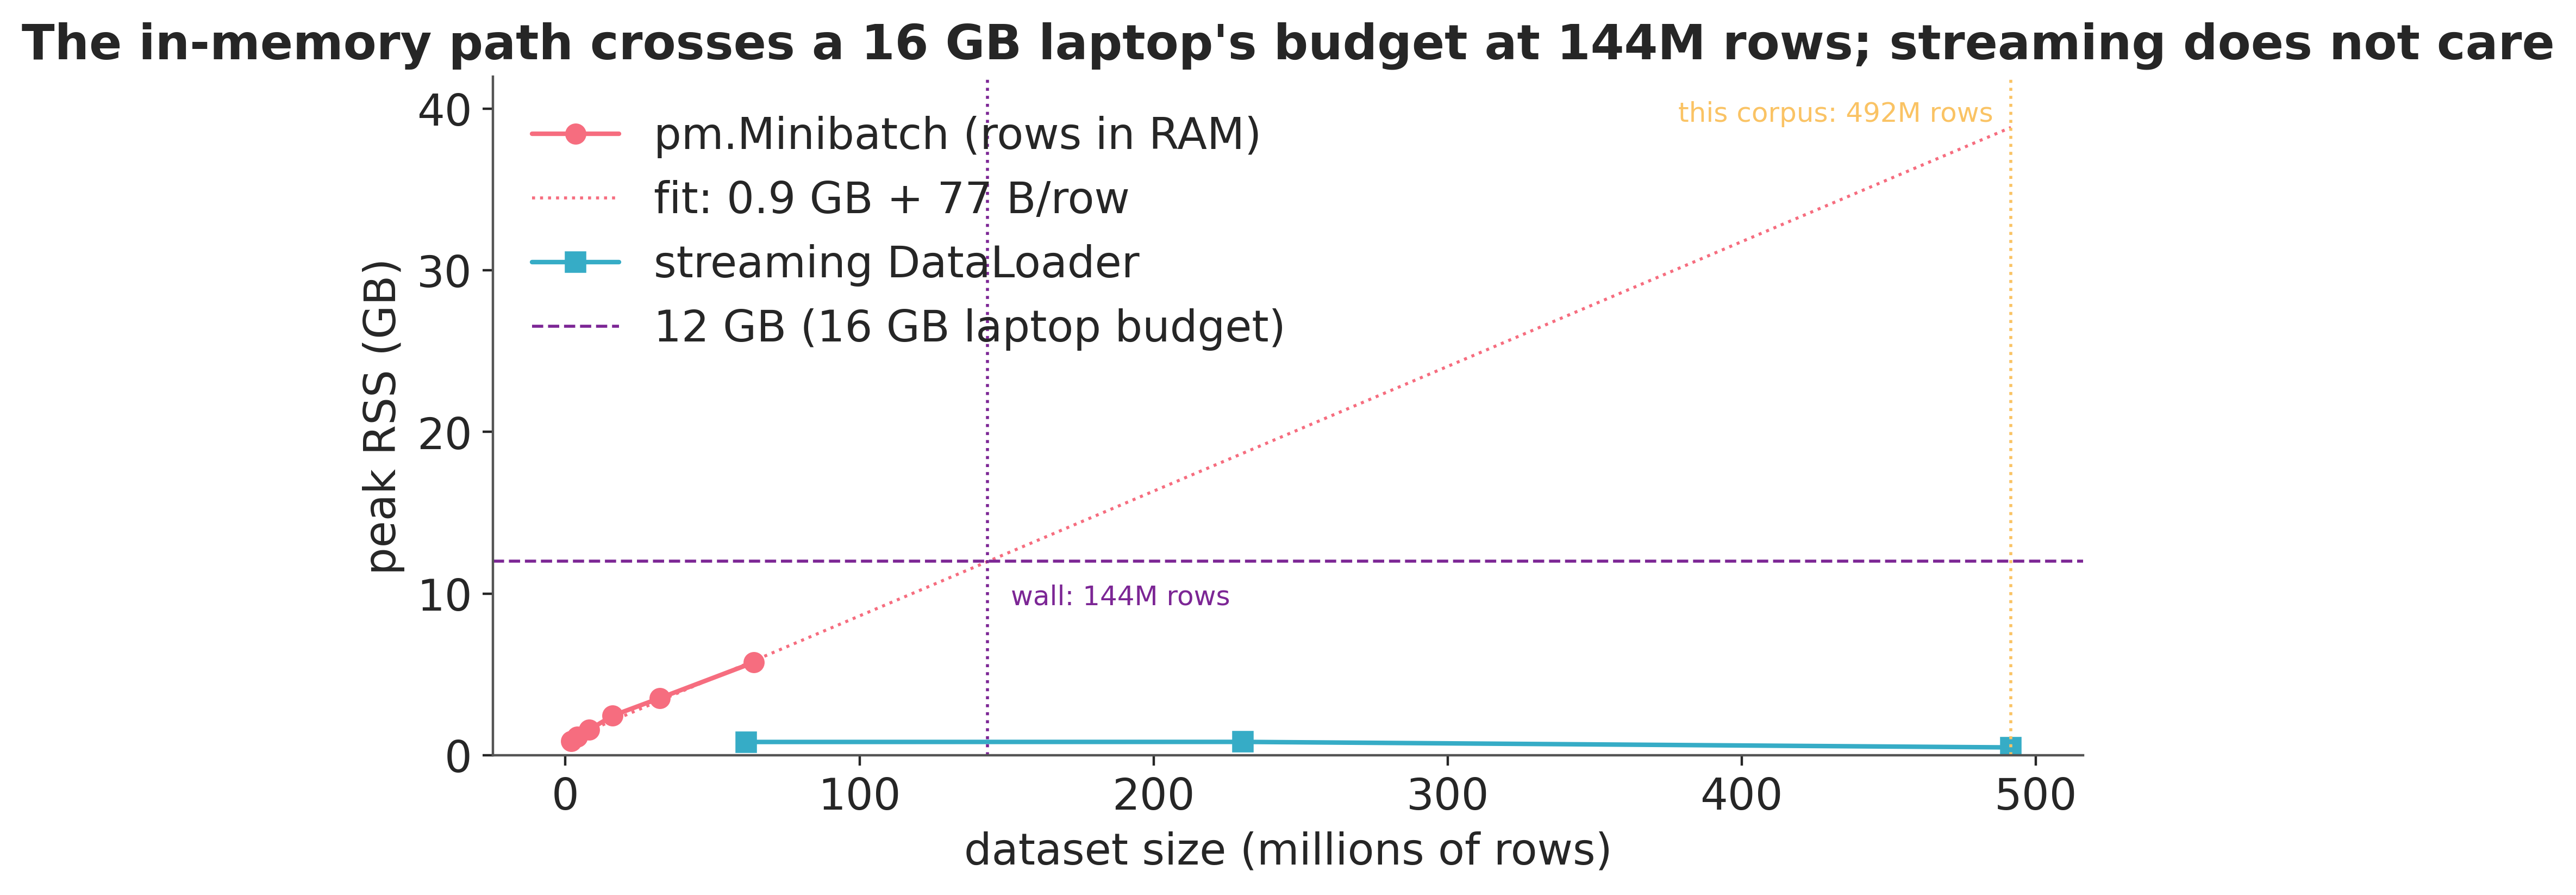

In [20]:
with open("streaming_tick_data_results.json") as f:
    results = json.load(f)

mb = np.array(results["memwall"]["minibatch"], dtype=float)
st = np.array(results["memwall"]["stream"], dtype=float)
bpr = results["memwall"]["bytes_per_row"]
icpt = results["memwall"]["intercept_gb"]
cross = results["memwall"]["crossing_rows_12gb"]
n_full = results["corpus"]["n_rows"]

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.plot(mb[:, 0] / 1e6, mb[:, 1], "o-", color="C1", label="pm.Minibatch (rows in RAM)")
grid = np.linspace(0, n_full, 200)
ax.plot(
    grid / 1e6,
    icpt + bpr * grid / 1e9,
    ls=":",
    color="C1",
    lw=1,
    label=f"fit: {icpt:.1f} GB + {bpr:.0f} B/row",
)
ax.plot(st[:, 0] / 1e6, st[:, 1], "s-", color="C0", label="streaming DataLoader")
ax.axhline(12, color="C3", ls="--", lw=1, label="12 GB (16 GB laptop budget)")
ax.axvline(cross / 1e6, color="C3", ls=":", lw=1)
ax.annotate(
    f"wall: {cross / 1e6:,.0f}M rows",
    (cross / 1e6 + 8, 10.6),
    color="C3",
    fontsize=9,
    ha="left",
    va="top",
)
ax.axvline(n_full / 1e6, color="C2", ls=":", lw=1)
ax.set_ylim(0, 42)
ax.annotate(
    f"this corpus: {n_full / 1e6:,.0f}M rows",
    (n_full / 1e6 - 6, 40.5),
    color="C2",
    fontsize=9,
    ha="right",
    va="top",
)
ax.set_xlabel("dataset size (millions of rows)")
ax.set_ylabel("peak RSS (GB)")
ax.set_title(
    "The in-memory path crosses a 16 GB laptop's budget at "
    f"{cross / 1e6:,.0f}M rows; streaming does not care"
)
ax.legend(loc="upper left");

The corpus behind this notebook sits at roughly three times the wall.

:::{warning}
Two caveats belong next to this figure, not in a footnote. The in-memory arm
was measured up to 64M rows and the crossing is a *projection* from the fitted
line — macOS does not enforce `RLIMIT_AS`, so a demonstrated hard failure
needs a memory-capped Linux subprocess. And the two samplers differ
semantically: `pm.Minibatch` draws with replacement, the loader makes
without-replacement epoch passes.
:::

And speed? Steady-state, compile time subtracted, same model:

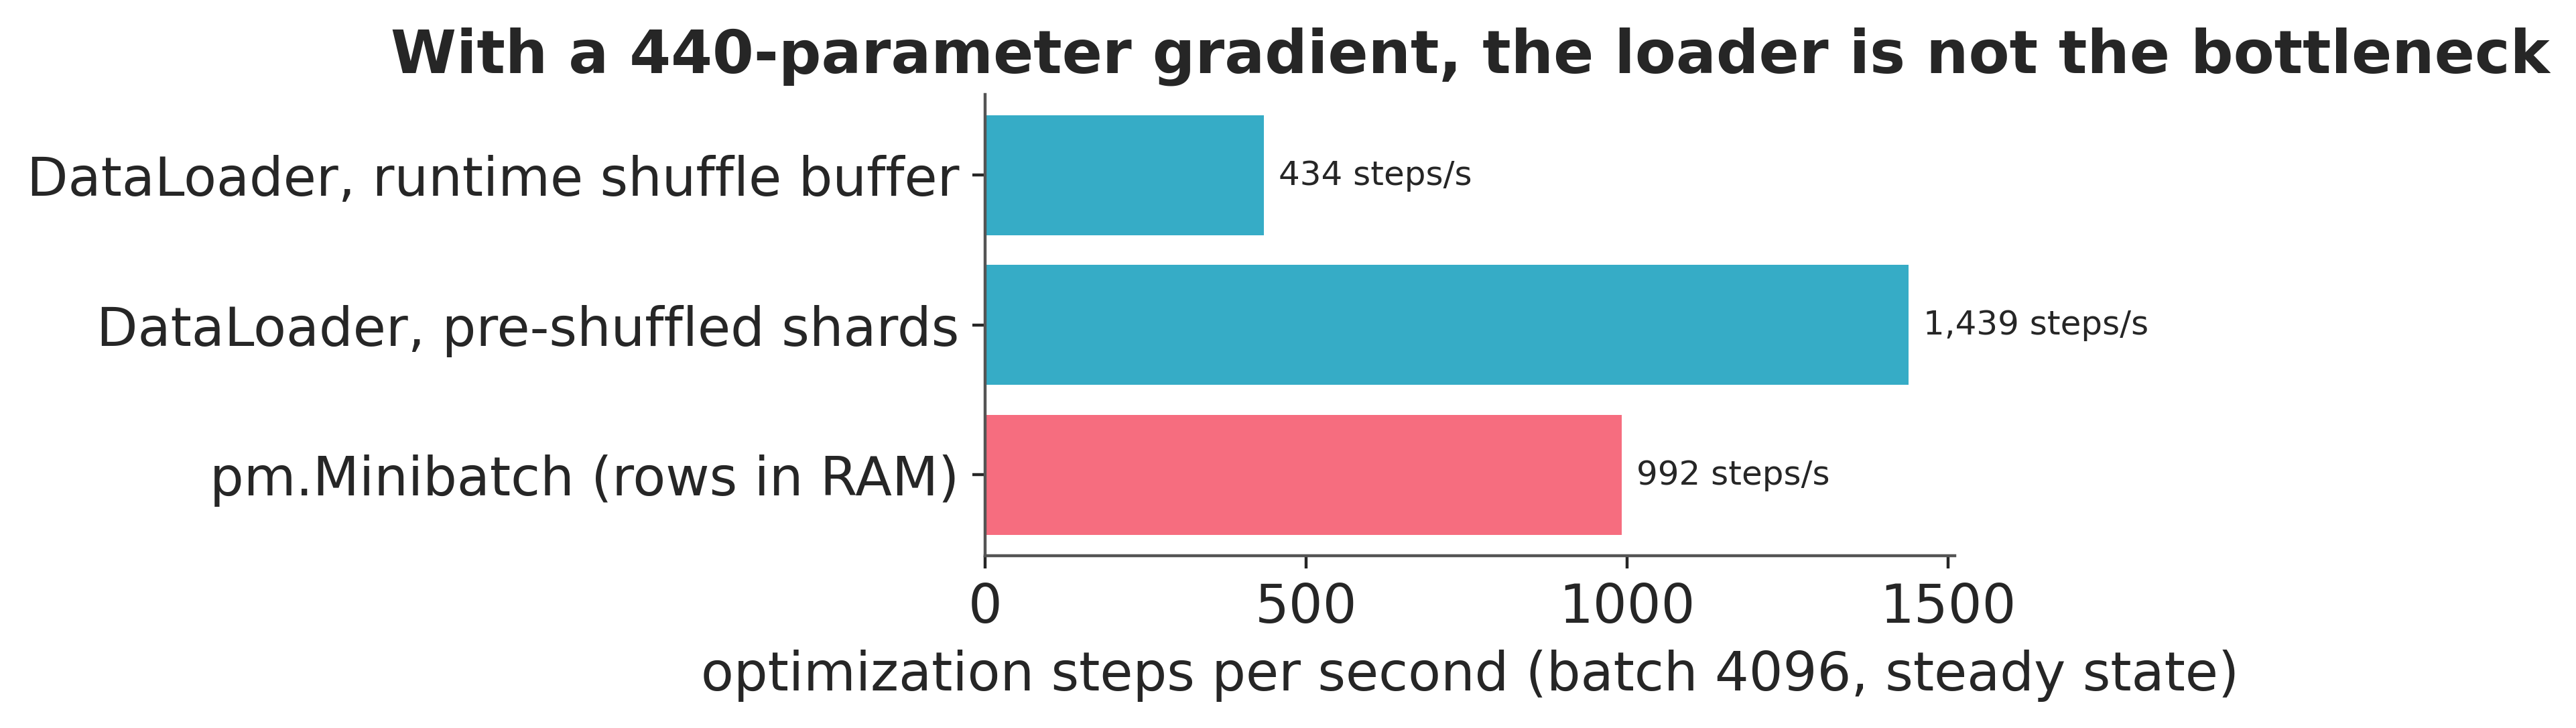

In [21]:
tp = results["memwall"]["throughput"]
labels = {
    "minibatch": "pm.Minibatch (rows in RAM)",
    "stream": "DataLoader, pre-shuffled shards",
    "stream_shuffled": "DataLoader, runtime shuffle buffer",
}
fig, ax = plt.subplots(figsize=(8, 2.6), layout="constrained")
names = [labels[k] for k in labels]
vals = [tp[k] for k in labels]
ax.barh(names, vals, color=["C1", "C0", "C0"])
for bar_y, val in enumerate(vals):
    ax.annotate(
        f"{val:,.0f} steps/s",
        (val, bar_y),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
    )
ax.set_xlabel("optimization steps per second (batch 4096, steady state)")
ax.set_title("With a 440-parameter gradient, the loader is not the bottleneck");

The ordering surprised us, so it is worth stating carefully. On this model the
gradient dominates the step, and the pre-shuffled streaming path *outpaces*
in-RAM `pm.Minibatch` — the loader's Python-level handoff is cheaper than
Minibatch's per-step random indexing. On our lighter probe model the same
ordering held (pre-shuffled loader ~4,900 vs Minibatch ~3,000 steps/s), so
treat any speed ordering as an empirical, model-specific fact rather than a
law in either direction. The one consistently
expensive path is the runtime shuffle buffer — which is why the ETL-time
global shuffle matters twice: it is the *statistically* honest option, and it
is 3× the throughput.

### What the data did to the model

Three findings from the first full-scale fits are worth more than any smooth
success story:

**Non-centered effects collapsed under mean-field.** The first version of this
model used the textbook non-centered parameterization
$b_s = \tau \cdot z_s,\ z_s \sim \mathcal{N}(0,1)$. On the real corpus the
$z_s$ posteriors blew out to $+17$ while the $\tau$'s collapsed — some pinned
low against the prior, others (the hour-shape scale) driven far *below* its
bulk:
real cross-symbol volatility levels span two orders of magnitude, the original
$\tau$ prior could not reach them, and a mean-field approximation of the
$\tau$–$z$ funnel collapses into its small-$\tau$/huge-$z$ corner. Both fixes
are principled: weakly informative scale priors, and *centered* effects —
non-centering exists for data-poor groups, and with $10^5$–$10^8$ rows per
symbol these groups are anything but. One honest caveat: the two fixes were
applied together, so their individual contributions are confounded — a
same-prior centered/non-centered ablation would separate them, and the safe
reading is empirical rather than theoretical: on this corpus, this
combination fits cleanly and the original one did not.

**The variance does not exist.** With the conventional
$\nu = 2 + \operatorname{softplus}(\eta)$ parameterization, 450 million rows
pinned $\nu$ at the floor of exactly 2 with a posterior standard deviation of
$2 \times 10^{-6}$ — the data demanding tails heavier than any
finite-variance Student-t. The parameterization was moved to a floor of 1 and
the estimand to quantile-based dispersion, which is finite for all $\nu > 0$.
With the floor out of the way, three independent seeds put $\nu$ at 1.895
with a seed spread of $8 \times 10^{-5}$ — an *interior* optimum below 2.
Within the fitted conditional-move Student-t, then, the variance simply does
not exist — a statement about this working likelihood on this corpus, not a
metaphysical claim about crypto returns — while the mean is finite and
quantiles behave, which is exactly why the estimand is quantile-based.

**The robust location disagrees with least squares about a sign.** Ordinary
least squares of $y$ on $\text{ylag}$ gives a *negative* coefficient
(bid-ask bounce, ≈ −0.24 on the held-out sample, moved rows only — the exact
value is specification-dependent); the fitted $\theta_r$ is *positive*
(+0.29, seed spread $8 \times 10^{-6}$). Direct likelihood profiling on a
million real rows
confirms the likelihood genuinely peaks at the positive value: small moves
(88% of rows) show continuation, large moves show reversal, and a heavy-tailed
likelihood follows the bulk while a quadratic loss follows the outliers.
Neither number is wrong — they answer different questions, and a robust
likelihood answers the one about typical transitions.

### The stopping rule at scale, and a pre-registration that failed

Two scoping sentences first, so no number below is ambiguous. Every held-out
score in this section comes from fits on the 60-shard training split only,
with the four held-out shards touched by nothing but the scorer (and, as
disclosed above, the ETL-time standardization constants estimated over the
full corpus) — the
headline four-minute fit above streams all 64 shards and is never
holdout-scored. And "held out" here means a hash-random *contemporaneous*
split over serially overlapping transitions (a holdout row's `ylag` can be a
training row's label), which is exactly what paired comparisons between
optimization arms need and nothing more — no forward-in-time validation is
claimed anywhere in this notebook. The stopping-rule comparison was pre-registered before any
full-scale run:
fixed budgets of ¼, ½, 1 and 2 passes versus the windowed rule, identical
batch order and seeds, flat learning rate; savings to be claimed only if the
stopped fit's held-out log score landed within max(2 × ref seed spread,
2·10⁻⁴) nats/row of the 2-pass reference. Because a flat learning rate makes
every budget a prefix of the same deterministic trajectory, all five arms per
seed come from one run with mid-flight snapshots — and the windowed rule ran
as a shadow observer, stopping (all three seeds) at 1.07 passes: the mandated
one-pass floor plus its designed $h/\kappa$-window detection delay, 46% below
the reference budget (each protocol is replicated below). Stated plainly,
because it would be easy to bury: the fixed 1-pass budget *dominated* the
monitor here — fewer steps, a better held-out score, and it passed the
pre-registered test the monitor failed — so on this corpus the rule's value
is certifying the plateau, not saving steps beyond a well-chosen budget.

In [22]:
conv = pd.DataFrame(
    [(arm, passes, *scores) for arm, passes, scores in results["converge_table"]],
    columns=["arm", "passes", "seed 0", "seed 1", "seed 2"],
).set_index("arm")
conv

,passes,seed 0,seed 1,seed 2
arm,,,,
e0.25,0.25,0.117919,0.117978,0.117858
e0.5,0.50,0.117867,0.117869,0.117858
e1.0,1.00,0.117009,0.117014,0.117002
e2.0,2.00,0.117014,0.117003,0.117013
monitor,1.07,0.116262,0.116299,0.116323


**The equivalence test failed** — and not in the direction anyone would
guess: the ¼- and ½-pass arms *out-scored* the 1- and 2-pass arms by about
$10^{-3}$ nats/row — 74–88× the tightest arms' seed spreads (per-arm spreads
run $6\times10^{-6}$ to $6\times10^{-5}$ (sample sd), and batch order is shared across
seeds, so these exclude data-order variation) — while the 1- and
2-pass arms tied within seed spread, and the monitor arm under-scored
everything. The loss trace suggests why: this fit reaches its loss plateau
within a quarter pass, so all flat-rate arms sit on the same plateau, where
the held-out score of a *point* estimate moves with the optimizer's state at
flat learning rate 0.02 — consistent with Adam's stationary jitter and
position along the (seed-shared) batch cycle, though these artifacts alone
cannot separate that from other path effects. So we ran the replicated
follow-up the failure demanded: three seeds per protocol for an annealed
2-pass reference, a quarter-pass budget plus a 2,000-step anneal, a 1-pass
budget plus the same anneal, and the monitor's stop (1.07 passes) plus the
same anneal. One epistemic label before the numbers: these arms were chosen
*after* seeing the first round, and they score on the same contemporaneous
split — so what replication establishes is the seed-stability of the ranking
on this split, not an independent out-of-sample confirmation.

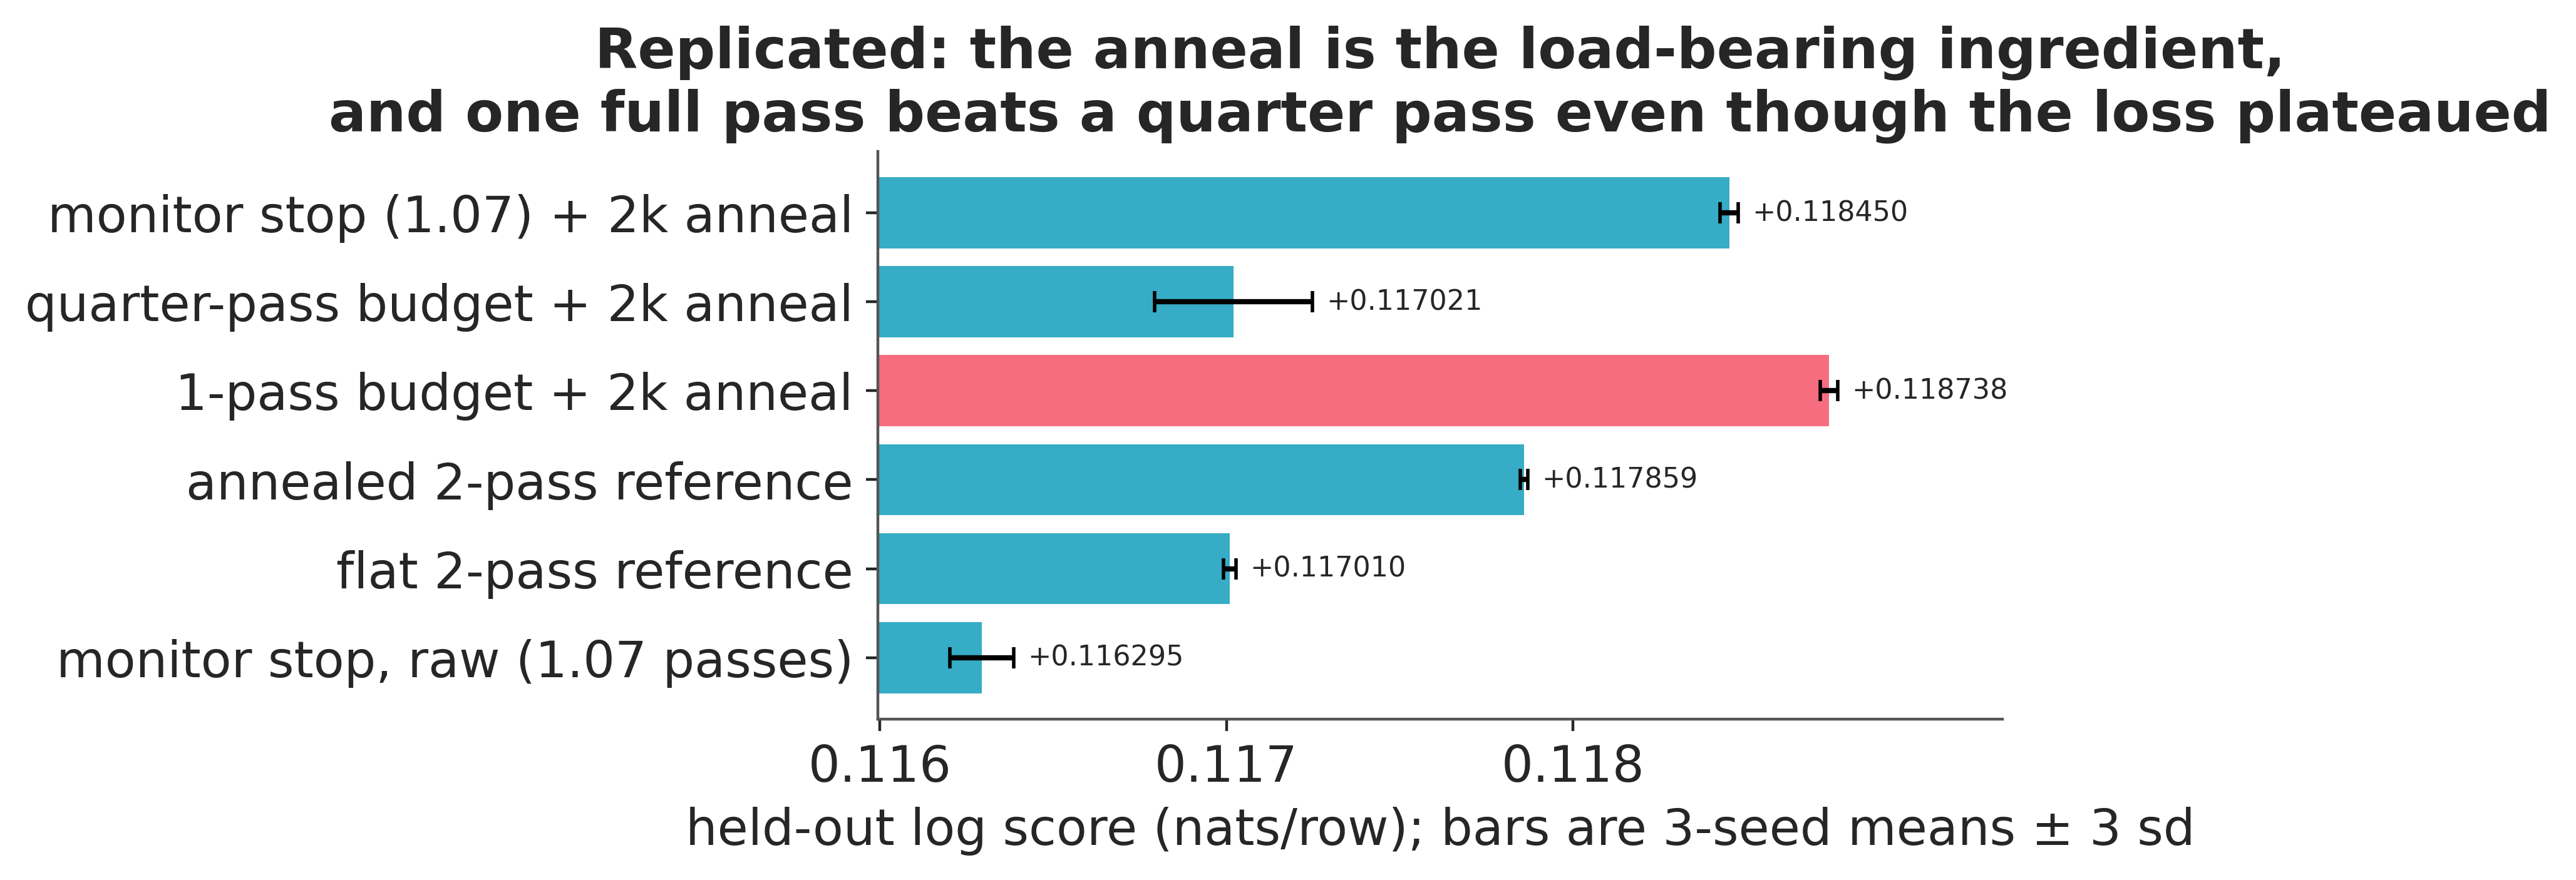

In [23]:
conf = results["confirm"]
flat_ref = np.array(conv.loc["e2.0", ["seed 0", "seed 1", "seed 2"]], dtype=float)
mon_raw = np.array(conv.loc["monitor", ["seed 0", "seed 1", "seed 2"]], dtype=float)
arms = {
    "monitor stop, raw (1.07 passes)": (mon_raw.mean(), mon_raw.std(ddof=1)),
    "flat 2-pass reference": (flat_ref.mean(), flat_ref.std(ddof=1)),
    **{k: (v["mean"], v["sd"]) for k, v in conf.items()},
}
fig, ax = plt.subplots(figsize=(8, 3.4), layout="constrained")
names = list(arms.keys())
means = [arms[n][0] for n in names]
sds = [arms[n][1] for n in names]
ax.barh(
    names,
    means,
    xerr=[3 * s for s in sds],
    color=["C1" if "1-pass budget" in n else "C0" for n in names],
    capsize=3,
)
for bar_y, (val, sd_) in enumerate(zip(means, sds)):
    ax.annotate(
        f"{val:+.6f}",
        (val + 3 * sd_, bar_y),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        fontsize=8,
    )
ax.set_xlim(min(means) - 3e-4, max(means) + 5e-4)
ax.set_xticks([0.116, 0.117, 0.118])
ax.set_xlabel("held-out log score (nats/row); bars are 3-seed means ± 3 sd")
ax.set_title(
    "Replicated: the anneal is the load-bearing ingredient,\n"
    "and one full pass beats a quarter pass even though the loss plateaued"
);

Three seeds per arm resolve the picture sharply — within-arm spreads are
$4 \times 10^{-6}$ to $8 \times 10^{-5}$, so every gap below is tens of
spreads wide (with one caveat: seeds vary the Monte-Carlo noise, not the
batch order, which is shared). Four replicated facts:

1. **The anneal is load-bearing.** At exactly matched budgets, the annealed
   2-pass reference beats the flat 2-pass arm by $8.5 \times 10^{-4}$; the
   1-pass budget plus a 2,000-step anneal (0.118738) beats the flat 1-pass
   arm by $1.7 \times 10^{-3}$ for 1.8% extra steps.
2. **The training-loss plateau is not a held-out plateau.** The loss flattens
   within a quarter pass, but the quarter-pass-plus-anneal arm (0.117021)
   trails the 1-pass-plus-anneal arm by $1.7 \times 10^{-3}$: between ¼ and 1
   pass the model keeps improving where the loss trace cannot show it. The
   one-full-pass floor earns its keep after all.
3. **The stop rule adds nothing beyond the floor here.** Its stop
   (1.07 passes) plus anneal (0.118450) sits $2.9 \times 10^{-4}$ *below* the
   plain 1-pass budget plus anneal — the detection delay bought 7% more flat-lr
   steps and a slightly worse endpoint. On this corpus the rule's value is
   certifying the plateau, not choosing a better stop than a well-chosen
   budget.
4. **More budget is not better.** The fully annealed 2-pass reference
   (0.117859) trails 1-pass-plus-short-anneal by $8.8 \times 10^{-4}$: the
   endpoint depends on the schedule, not the step count.

This also retires our own earlier reading: the "$5 \times 10^{-4}$ path
noise between annealed runs" was a *protocol* difference wearing a noise
costume — replicates of the same protocol agree to $10^{-4}$ or better, most
to $10^{-5}$. And it sharpens the pre-registration post-mortem: the mistake
was not the $2 \times 10^{-4}$ floor but the yardstick — the pre-registered
flat 2-pass reference sits $1.7 \times 10^{-3}$ off the tested frontier, and
even the annealed 2-pass comparator sits $8.8 \times 10^{-4}$ off it, so
equivalence to either measures loyalty, not quality.

The working protocol this ablation supports: **one full pass at the working
learning rate, then a short anneal** — with the stopping rule certifying the
training-loss plateau (it is the held-out ablation, not the rule, that shows
one pass sufficed among the schedules tested), and equivalence judged after
the anneal, on held-out score, against the best arm rather than a
conventional reference. That finding — not any savings headline — is what we
would want a reader to take away, and it fed directly back into the design
discussion of the upstream pull requests.

### The estimand: dispersion on the event clock

What the model is *for*: per symbol and hour, the probability that a trade
moves the price at all, and how far it typically goes when it does (posterior:
the all-shard headline fit — these curves are estimates, not scored claims).
Both come
from the posterior of the fitted links at reference covariates, so the
intraday shape below is pooled across the hierarchy — BTC's curve is almost
entirely its own data, the thin symbols' curves borrow the global harmonics
exactly as the model intends:

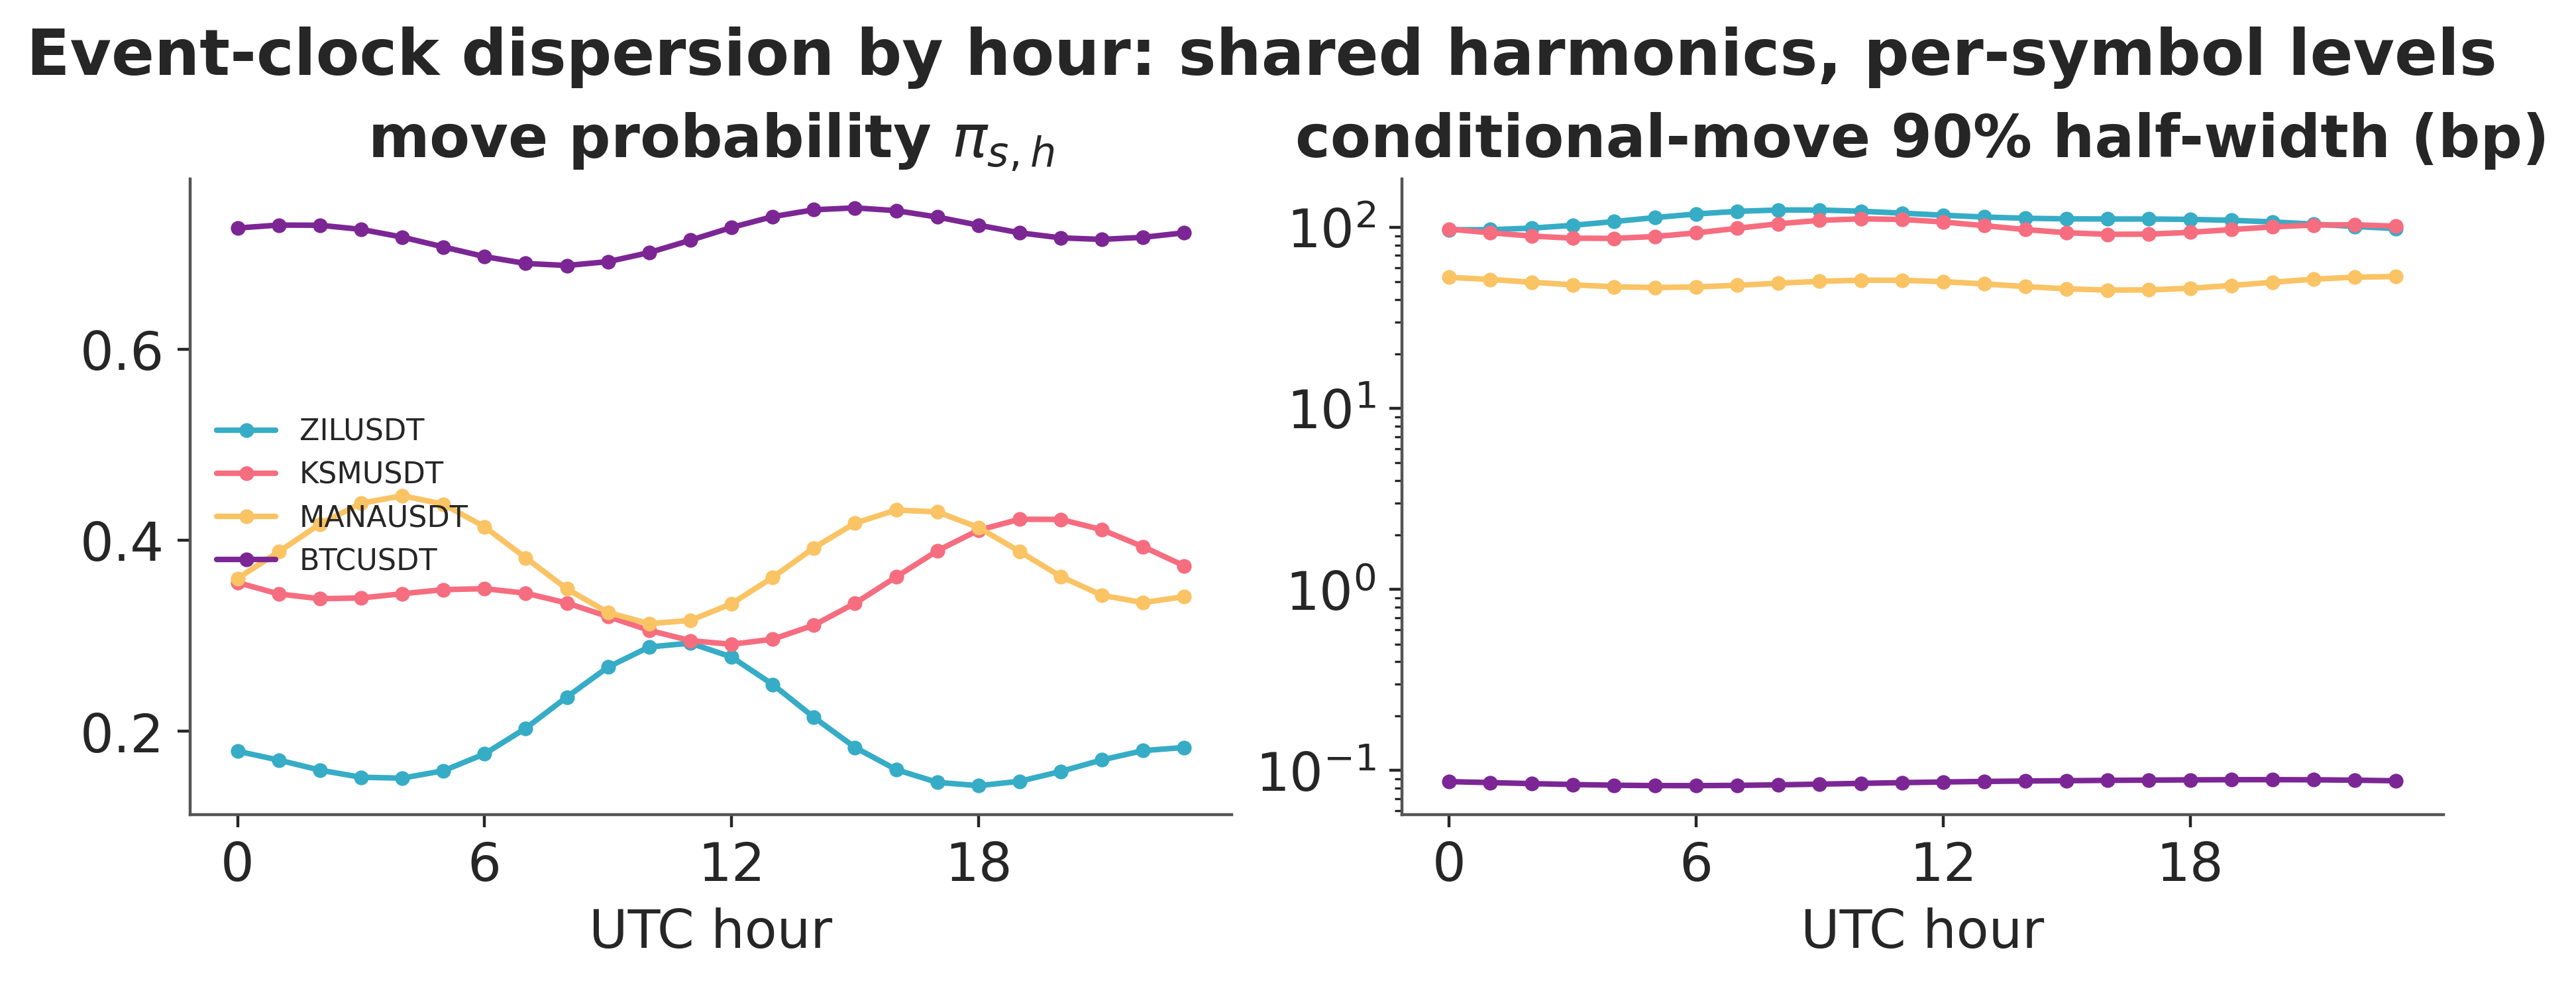

In [24]:
hours = np.arange(24)
fig, axs = plt.subplots(1, 2, figsize=(9, 3.6), sharex=True, layout="constrained")
for sym_name, _ in results["forest_symbols"]:
    disp = results["dispersion_full"][sym_name]
    axs[0].plot(hours, disp["pi_mean"], marker=".", label=sym_name)
    axs[1].plot(hours, disp["hw_mean"], marker=".")
    axs[1].fill_between(
        hours,
        np.array(disp["hw_mean"]) - 2 * np.array(disp["hw_sd"]),
        np.array(disp["hw_mean"]) + 2 * np.array(disp["hw_sd"]),
        alpha=0.2,
    )
axs[0].set_title(r"move probability $\pi_{s,h}$")
axs[1].set_title("conditional-move 90% half-width (bp)")
axs[1].set_yscale("log")
for ax in axs:
    ax.set_xlabel("UTC hour")
    ax.set_xticks(range(0, 24, 6))
axs[0].legend(fontsize=8, loc="center left")
fig.suptitle("Event-clock dispersion by hour: shared harmonics, per-symbol levels");

Read it as event time, not clock time: these are per-*transition* quantities,
and the number of transitions per hour itself varies enormously — the two
clocks tell different stories and this notebook only claims the first.

### What full N buys: thin cells

A uniform 1% subsample (4.6M rows — 1% of the 60-shard training split, drawn
by taking the hash-ordered head of each shard, with the last four shards held
out for scoring) can estimate every *global* parameter of this model — and did,
matching the full fit closely on the well-determined ones (ν to 0.1%, the
θ's, λ_q, τ_α) and agreeing in sign and rough magnitude on the small
coefficients that wander between full-N configurations too. So why stream
100× more
data? Because the estimand lives in symbol-by-hour cells, and the thin end of
the universe is where the two fits part ways. Below, the posterior of the
conditional-move 90% half-width $\sigma_{s,h}\, t^{-1}_{0.95}(\nu)$ at
reference covariates, full fit versus 1% subsample, for the thinnest and the
fattest symbols in the corpus:

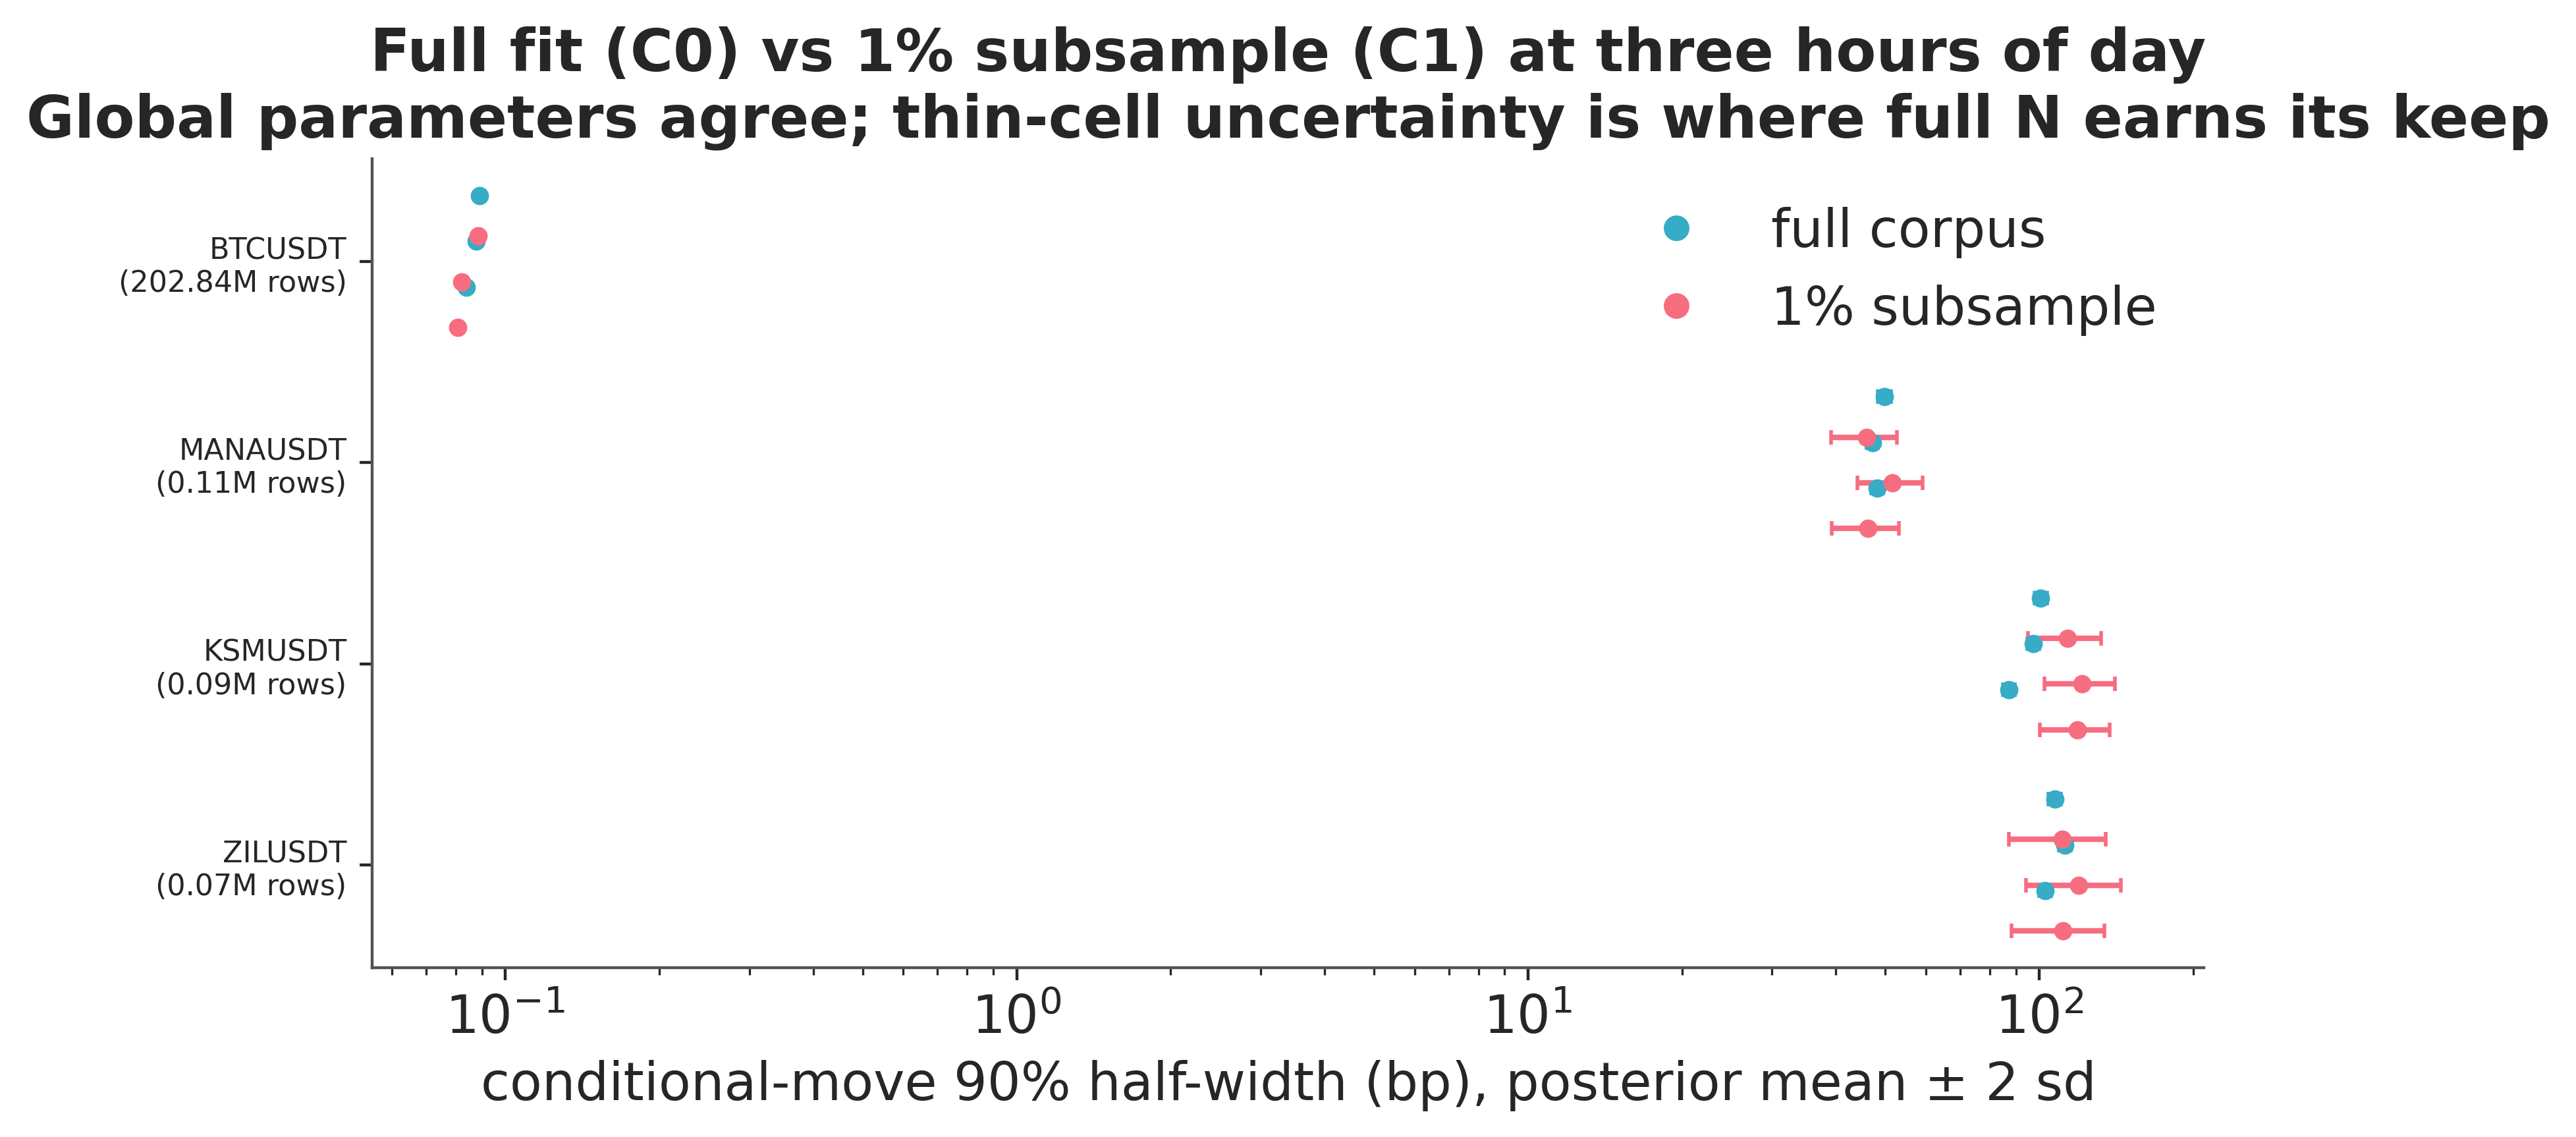

In [25]:
disp_full = results["dispersion_full"]
disp_sub = results["dispersion_sub1pct"]
show_syms = results["forest_symbols"]  # thinnest three + BTC, with row counts
show_hours = [3, 14, 20]

fig, ax = plt.subplots(figsize=(8, 4.2), layout="constrained")
ypos = 0
labels, ticks = [], []
for sym_name, n_rows in show_syms:
    for arm, color, off in [(disp_full, "C0", 0.22), (disp_sub, "C1", -0.22)]:
        hw = arm[sym_name]
        for hi, h in enumerate(show_hours):
            hw_m, hw_s = hw["hw_mean"][h], hw["hw_sd"][h]
            ax.errorbar(
                [hw_m],
                [ypos + off + 0.5 * (hi - 1)],
                xerr=[[2 * hw_s], [2 * hw_s]],
                fmt="o",
                ms=4,
                color=color,
                capsize=2,
            )
    labels.append(f"{sym_name}\n({n_rows / 1e6:.2f}M rows)")
    ticks.append(ypos)
    ypos += 2.2
ax.set_yticks(ticks)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("conditional-move 90% half-width (bp), posterior mean ± 2 sd")
ax.set_title(
    "Full fit (C0) vs 1% subsample (C1) at three hours of day\n"
    "Global parameters agree; thin-cell uncertainty is where full N earns its keep"
)
ax.plot([], [], "o", color="C0", label="full corpus")
ax.plot([], [], "o", color="C1", label="1% subsample")
ax.legend();

This is a capacity-and-estimand demonstration, not a claim of method
superiority: the subsample answers global questions at 1% of the cost.

:::{warning}
No stratified oversampling of thin symbols, however tempting: unequal
inclusion probabilities break the plain `total_size` rescaling. The subsample
is uniform or it is invalid.
:::

### What we do not sweep under the rug

The single most useful diagnostic this notebook can leave you with costs
three fits and one table: the reported mean-field standard deviation next to
the sample standard deviation of the posterior mean across three optimizer
seeds. Read it as a *computational-stability* diagnostic. A ratio far above
one is disqualifying — the reported width understates even run-to-run
variation, so it cannot be trusted. A ratio near or below one is merely
*necessary*: the width survives seed replication, but certifying it as
calibrated would take a full-rank or MCMC comparison on a tractable
subproblem, which is future work here:

In [26]:
spread = pd.DataFrame(results["seed_spread"]).T
spread["ratio"] = (spread["seed_spread"] / spread["reported_sd"]).round(1)
spread.sort_values("ratio", ascending=False)

,posterior_mean,reported_sd,seed_spread,ratio
alpha0,-1.570000,0.000064,0.028130,442.1
beta_a,0.053680,0.000077,0.005310,69.0
kappa0,0.336200,0.000151,0.008867,58.7
theta_d,0.025290,0.000001,0.000008,6.1
eta,0.369200,0.000237,0.000134,0.6
nu,1.895000,0.000140,0.000079,0.6
lambda_a,0.056380,0.000139,0.000022,0.2
lambda_q,-0.392800,0.000113,0.000023,0.2
beta_q,-0.001442,0.000108,0.000010,0.1
theta_r,0.294700,0.000076,0.000008,0.1


- **Mean-field understates uncertainty along soft ridges.** The intercepts
  share a ridge with their pooled group means (only the sums are identified),
  and across repeated seeds the spread of $\alpha_0$ is roughly 440× its
  reported posterior standard deviation — $\kappa_0$ and $\beta_a$ show the
  same signature at 60–70×. The parameters *without* a ridge ($\theta_r$,
  $\nu$, $\lambda_a$, the $\tau$'s) sit at or below one, and $\theta_d$ sits
  in between (≈6). Report mean-field standard deviations only for parameters
  you have seed-checked — and remember the check bounds the error from below.
- **The speed ordering is model-dependent.** Here the heavy gradient hides
  the loader entirely and pre-shuffled streaming outpaces in-RAM
  `pm.Minibatch` — and did so on our lighter probe as well. Streaming's claim
  is memory and scale — treat any steps-per-second comparison as specific to
  the model it was measured on.
- **Sampling semantics differ**: `pm.Minibatch` draws with replacement; the
  loader makes without-replacement epoch passes.
- **Discreteness at the smallest moves.** Price changes are integer multiples
  of the tick size; the continuous Student-t is a working approximation whose
  residual misfit concentrates at |y| near one tick.
- **Event time is not clock time.** All dispersion statements are per
  transition, not per minute; activity itself varies by hour, and conflating
  the two clocks changes the intraday story.

## Where the pieces live

:::{seealso}
The `DataLoader`/`parquet_source` used here are in
[pymc-extras#698](https://github.com/pymc-devs/pymc-extras/pull/698); a
callback-free `Trainer` wrapper
([pymc-extras#710](https://github.com/pymc-devs/pymc-extras/pull/710)) and the
convergence monitor ([pymc#8384](https://github.com/pymc-devs/pymc/pull/8384))
are under review, and this notebook's callback pattern is exactly what those
APIs wrap. The ETL and full-scale run scripts accompany the submission, and
the {ref}`streaming_dataset` companion covers the API mechanics.
:::

## Authors

* Authored by [Yicheng Yang](https://github.com/YichengYang-Ethan) in August
  2026 for the Google Summer of Code project *Streaming Variational Inference
  for Large Datasets* (PyMC / NumFOCUS).

## References

:::{bibliography}
:filter: docname in docnames
:::

## Watermark

In [27]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,pymc_extras

Last updated: Tue, 11 Aug 2026

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 9.16.0

pytensor   : 3.1.3
pymc_extras: 0.13.1.dev4+gf8c50e5c6

arviz      : 1.2.0
json       : 2.0.9
logging    : 0.5.1.2
matplotlib : 3.10.9
numpy      : 2.4.6
pandas     : 3.0.3
pyarrow    : 25.0.0
pymc       : 6.1.0
pymc_extras: 0.13.1.dev4+gf8c50e5c6
pytensor   : 3.1.3

Watermark: 2.6.0



:::{include} ../page_footer.md
:::